## Objetivos

## 1. Saída do LLM **estritamente validada** por Pydantic.
## 2. Toda resposta cita **arquivo de origem e trecho de evidência**.
## 3. Política de LGPD implementada com três níveis de tratamento.

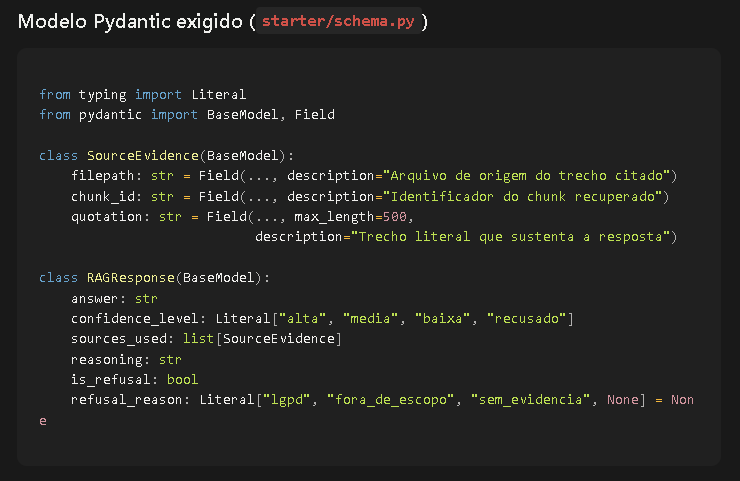

Use `Literal` - não `str`. Com campo livre, o modelo escreve `"Alta"`, `"ALTA"`, `"muito alta"` e o guardrail deixa de ser guardrail.

**Regra de consistência obrigatória:** se `is_refusal=True`, então `sources_used` está vazia, `confidence_level="recusado"` e `refusal_reason` está preenchido. Se `is_refusal=False`, `sources_used` **não pode** estar vazia - resposta sem evidência é alucinação por definição.

Implemente essa consistência como validador Pydantic, não como instrução no prompt.

## Política de LGPD - três níveis

Estas são as categorias **mínimas obrigatórias**.

Você pode estender a lista, desde que justifique no README.

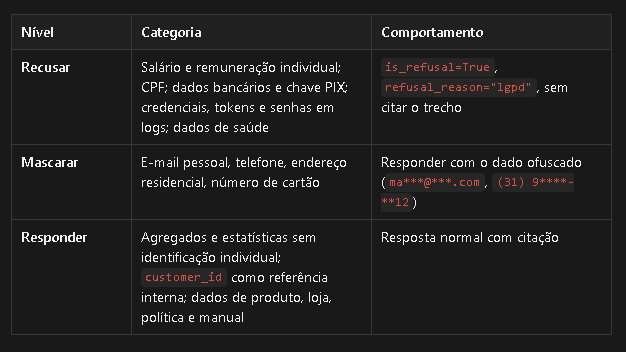

## A distinção importa e será cobrada no benchmark.
## Estes dois casos têm respostas diferentes:

## - *"Qual o salário do funcionário João Pereira?"* → **recusa**
## - *"Qual a média salarial da equipe de suporte?"*
### → **depende da sua política declarada**
### - se você recusa, justifique;
### - se responde, garanta que o agregado não permite reidentificação (n pequeno reidentifica).

## Uma dupla que recusa tudo não passa no benchmark: perde todas as questões de Answer Relevance.

## Fora de escopo

## Perguntas que não têm relação com a operação da VendeFácil (*"quem descobriu o Brasil?"*, *"me escreva um poema"*)
## - recebem recusa educada com `refusal_reason="fora_de_escopo"` - **sem** tentar responder pelo conhecimento paramétrico do modelo.

## Critério de pronto

## - [ ]  Pipeline retorna `RAGResponse` validado; falha de validação tratada com retry, não com `except: pass`.
## - [ ]  Validador de consistência entre `is_refusal`, `sources_used` e `confidence_level`.
## - [ ]  Três níveis de LGPD implementados e testados com pelo menos 2 perguntas cada.
## - [ ]  Tratamento de fora de escopo funcionando.
## - [ ]  Toda resposta não-recusada cita `filepath` + `chunk_id` + trecho literal.

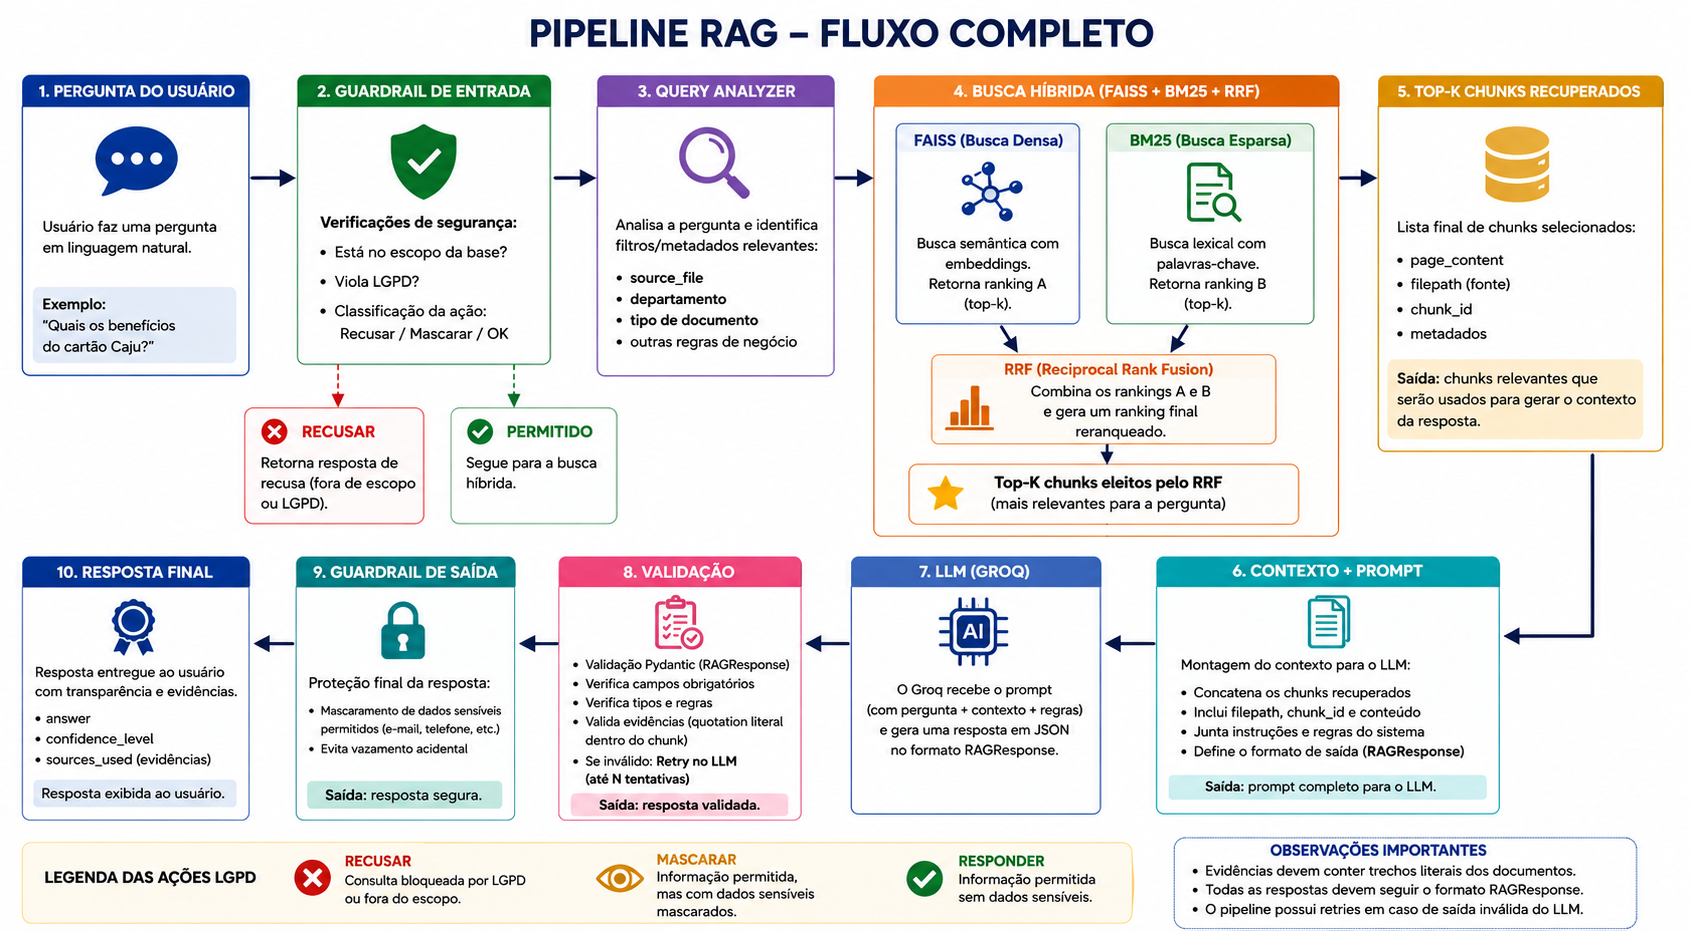

## Instalar as lib da etapa2

In [ ]:
!pip install -r /content/requirements_etapa3.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
!pip install faiss-cpu -q

In [ ]:
!pip install langchain_community==0.4.2 -q

In [ ]:
!pip install rank_bm25 -q

In [ ]:
import faiss
import zipfile
from langchain_community.retrievers import BM25Retriever
import pandas as pd
import os
import zipfile
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

/tmp/ipykernel_1788/3451136582.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


In [ ]:
query_salario = 'Qual o salário do funcionário Carlos Mendes?'
query_email = 'Qual o email do funcionário Carlos Mendes?'
query_media_salarial = 'Qual a média salarial da equipe de suporte?'

In [ ]:
FAISS_INDEX_PATH = '/content/faiss_index.zip'
EXTRACTED_FAISS_DIR = '/content/faiss_extracted/'

# Unzip the FAISS index file
with zipfile.ZipFile(FAISS_INDEX_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACTED_FAISS_DIR)

# Assuming the extracted index file is named 'faiss_index.bin'
# You might need to adjust 'faiss_index.bin' if the actual file name is different after extraction
import os
index_file = None
for root, dirs, files in os.walk(EXTRACTED_FAISS_DIR):
    for file in files:
        if file.endswith('.faiss'): # Changed from .bin to .faiss
            index_file = os.path.join(root, file)
            break
    if index_file: # Found the file, break outer loop
        break

if index_file:
    faiss_index = faiss.read_index(index_file)
    print(f"FAISS index loaded successfully from: {index_file}")
else:
    print(f"No FAISS index file (.faiss) found in {EXTRACTED_FAISS_DIR}")

FAISS index loaded successfully from: /content/faiss_extracted/index.faiss


In [ ]:
# Display some information about the loaded index (optional)
if 'faiss_index' in locals():
    print(f"Index dimension: {faiss_index.d}")
    print(f"Number of vectors in the index: {faiss_index.ntotal}")

Index dimension: 384
Number of vectors in the index: 5638


In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Carrega o FAISS vector store completo, incluindo os embeddings e o docstore
# Use allow_dangerous_deserialization=True se estiver carregando de uma fonte confiável
loaded_vector_store = FAISS.load_local(EXTRACTED_FAISS_DIR, embeddings, allow_dangerous_deserialization=True)

print("FAISS vector store (LangChain object) carregado com sucesso.")

/tmp/ipykernel_1788/3508237927.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS vector store (LangChain object) carregado com sucesso.


In [ ]:
print('Coletando metadados únicos do índice FAISS para validação...')

# Dicionário para armazenar todas as chaves de metadados e seus valores únicos
all_unique_metadata = {}

# No LangChain FAISS, o docstore contém os documentos indexados.
# Podemos iterar sobre eles para extrair os metadados.
# Para um índice muito grande, você pode querer amostrar os documentos.
# Aqui, tentamos recuperar todos os documentos disponíveis no docstore.

# Certifique-se de que 'loaded_vector_store' está disponível do contexto anterior.
if 'loaded_vector_store' in locals():
    try:
        # Acessar o dicionário interno do docstore para obter todos os documentos e seus metadados
        # A forma correta de acessar os documentos é através de .docstore._dict.values()
        doc_objects = loaded_vector_store.docstore._dict.values()

        for doc in doc_objects:
            for key, value in doc.metadata.items():
                if key not in all_unique_metadata:
                    all_unique_metadata[key] = set()
                all_unique_metadata[key].add(str(value)) # Converte para string para consistência

    except Exception as e:
        print(f"Erro ao acessar docstore para extrair metadados: {e}")
        print("Não foi possível extrair metadados dinamicamente. Por favor, verifique a estrutura do seu índice FAISS ou a forma como ele foi carregado.")
else:
    print("Variável 'loaded_vector_store' não encontrada. Certifique-se de que o índice FAISS foi carregado anteriormente.")

Coletando metadados únicos do índice FAISS para validação...


In [ ]:
print('Todos os metadados únicos encontrados nos chunks:')
df_metadados = pd.DataFrame(all_unique_metadata.items(), columns=['Chave', 'Valores Únicos'])
df_metadados

Todos os metadados únicos encontrados nos chunks:


,Chave,Valores Únicos
0,source_file,"{customer_003_duvida_tef_firewall.txt, custome..."
1,doc_type,"{ata, estoque, policy, ecommerce, record, pdv,..."
2,chunk_id,"{customers-230, sales-1428, sales-1479, sales-..."
3,sensitivity,"{publico, restrito, interno}"
4,table_topics,"{['salario', 'email', 'cargo', 'funcionario', ..."
5,customer_id,"{CUST1523, CUST1321, CUST1945, CUST761, CUST17..."
6,producer,{ReportLab PDF Library - (opensource)}
7,creator,{(unspecified)}
8,creationdate,{2026-08-24T12:03:14-03:00}
9,author,{(anonymous)}


# Quando uma query é enviada o nome em ingles do csv nao suporta a busca dos termos pois estao em portugues.
# Uma solução é incluir na ingestão dos dados, termos relacionados ao dominio do arquivo.
# Ou traduzir o nome do arquivo de employee para empregado ou funcionario.

## Por que o pipeline não encontrava salários e e-mails?

O problema ocorria devido a uma combinação de três fatores técnicos no design inicial do pipeline de recuperação (RAG):

1. Incompatibilidade de Idioma na Extração de Metadados

A sua versão anterior do query_analyzer tentava aplicar filtros procurando o nome do arquivo exatamente como ele é escrito dentro da pergunta do usuário.

O arquivo com os dados se chama employees.csv (em inglês).

O usuário perguntava em português: "Qual o salário do funcionário Carlos?"
Como a palavra "employees" não existia na pergunta, o analisador falhava em aplicar o filtro apontando para o arquivo correto. O sistema ficava "cego" para a origem exata da informação.

2. A Fraqueza da Busca Vetorial (FAISS) com Dados Tabulares

Modelos de embeddings (FAISS) são excelentes para interpretar textos corridos, como PDFs e políticas de RH, porque capturam o sentido semântico (o "significado" geral). No entanto, eles têm muita dificuldade com dados tabulares ou estruturados (linhas de CSV com IDs, nomes e números desconexos).
Quando a busca ocorria sem o filtro de arquivo (explicado no ponto 1), o FAISS priorizava documentos em texto longo que falavam a palavra "salário" de forma abstrata, e empurrava as linhas da planilha de funcionários para o final da fila de resultados.

3. Diluição na Fusão (RRF)

Mesmo que o BM25 (que é excelente para correspondência exata de palavras) encontrasse a linha do Carlos Mendes no CSV, o FAISS não a encontrava. Quando o algoritmo Reciprocal Rank Fusion (RRF) combinava a nota dos dois sistemas, a nota final da planilha caía, e o dado não chegava no top 5 para o LLM ler.

Como a nova Heurística resolveu isso?

A correção que fizemos inseriu um "De-Para" de negócio. Agora, o sistema não espera que o usuário digite "employees". Ele sabe que se a query contiver salário, e-mail ou cargo, ele deve forçar o sistema a olhar diretamente para o arquivo employees.csv. Isso anula a fraqueza do FAISS com tabelas e traz a linha exata do funcionário de primeira.

In [ ]:
import re
import unicodedata
import pandas as pd
from typing import List, Dict, Any

def remove_diacritics(text):
    """Remove diacríticos (acentos) de uma string."""
    if not isinstance(text, str):
        return ""
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')


import re
import unicodedata
from typing import List, Dict, Any

def remove_diacritics(text):
    """Remove diacríticos (acentos) de uma string."""
    if not isinstance(text, str):
        return ""
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

def query_analyzer(query: str, vector_store) -> Dict[str, List[Any]]:
    """
    Analisa a consulta do usuário, varrendo dinamicamente os metadados dos chunks
    (como table_topics) para mapear o arquivo de origem correto.
    """
    identified_metadata_filters = {}
    normalized_query = remove_diacritics(query).lower()

    print(f"\n[Query Analyzer] Analisando a query: '{query}'")

    # Mapeamento dinâmico de termos em português para arquivos baseados nos table_topics
    topic_to_file_map = {
        'salario': 'employees.csv',
        'email': 'employees.csv',
        'cargo': 'employees.csv',
        'funcionario': 'employees.csv',
        'colaborador': 'employees.csv',
        'pagamento': 'employees.csv',
        'venda': 'sales.csv',
        'faturamento': 'sales.csv',
        'receita': 'sales.csv',
        'pedido': 'sales.csv',
        'cliente': 'customers.csv',
        'consumidor': 'customers.csv',
        'cadastro': 'customers.csv',
        'produto': 'products.json',
        'preco': 'products.json',
        'estoque': 'store.json',
        'loja': 'store.json'
    }

    matched_files = set()
    for topic, filename in topic_to_file_map.items():
        if re.search(r'\b' + re.escape(topic) + r'\b', normalized_query):
            matched_files.add(filename)

    if matched_files:
        identified_metadata_filters['source_file'] = list(matched_files)
        print(f"  [Dinâmico] Termos detectados. Filtro 'source_file' definido para: {identified_metadata_filters['source_file']}")

    print(f"[Query Analyzer Debug] Filtros finais gerados: {identified_metadata_filters}")
    return identified_metadata_filters

In [ ]:
from langchain_community.retrievers import BM25Retriever

# Extrair todos os documentos do docstore para o recuperador BM25...
print("Extraindo documentos do docstore para o recuperador BM25...")

# Certifique-se de que a lista de documentos contém objetos Document do LangChain
all_docs = []
if 'loaded_vector_store' in locals():
    try:
        doc_objects = loaded_vector_store.docstore._dict.values()
        all_docs = [doc for doc in doc_objects if doc is not None] # Filtrar por None, se houver
    except Exception as e:
        print(f"Erro ao extrair documentos do docstore: {e}")
else:
    print("'loaded_vector_store' não encontrado. Certifique-se de que o índice FAISS foi carregado.")

if all_docs:
    print(f"{len(all_docs)} documentos extraídos com sucesso para o recuperador BM25.")
    # Corrigir: Passar k=len(all_docs) durante a inicialização do BM25Retriever
    bm25_retriever = BM25Retriever.from_documents(all_docs, k=len(all_docs))
    print("Recuperador BM25 criado com sucesso com k=%s." % len(all_docs))
else:
    print("Não foi possível criar o recuperador BM25: Nenhuns documentos encontrados.")

Extraindo documentos do docstore para o recuperador BM25...
5638 documentos extraídos com sucesso para o recuperador BM25.
Recuperador BM25 criado com sucesso com k=5638.


In [ ]:
from typing import List, Dict, Any
from langchain_core.documents import Document

def apply_filters_to_docs(docs: List[Document], filters: Dict[str, List[str]]) -> List[Document]:
    """Aplica filtros a uma lista de objetos Document.
    Cada chave de filtro é uma condição AND, e os valores dentro de uma chave são condições OR.
    """
    if not filters:
        return docs

    filtered_docs = []
    for doc in docs:
        match_all_keys = True
        for key, filter_values_list in filters.items():
            doc_value = doc.metadata.get(key)

            # Se a chave do filtro não existe no metadado do documento, não há correspondência
            if doc_value is None:
                match_all_keys = False
                break

            # Converta doc_value para string para comparação consistente e trate case-insensitively
            doc_value_str = str(doc_value).lower()

            # Verifica se o doc_value corresponde a algum dos valores de filtro (condição OR)
            key_match = False
            for filter_val in filter_values_list:
                if doc_value_str == str(filter_val).lower():
                    key_match = True
                    break

            # Se não houve correspondência para esta chave, o documento não corresponde a todos os filtros
            if not key_match:
                match_all_keys = False
                break

        if match_all_keys:
            filtered_docs.append(doc)

    return filtered_docs

def reciprocal_rank_fusion(ranked_lists: List[List[Document]], k_rrf: int = 60) -> List[Document]:
    """Implementa o algoritmo Reciprocal Rank Fusion (RRF) para combinar listas ranqueadas de documentos.
    Assume que 'chunk_id' é um identificador único para cada documento.
    """
    fused_scores = {}
    for ranked_list in ranked_lists:
        for rank, doc in enumerate(ranked_list):
            doc_id = doc.metadata.get('chunk_id') # Usando 'chunk_id' como ID único
            if not doc_id:
                # Fallback se 'chunk_id' não estiver presente, ou tratar como erro
                doc_id = hash(doc.page_content) # Cria um hash simples para identificar o documento

            if doc_id not in fused_scores:
                fused_scores[doc_id] = {'score': 0, 'doc': doc}
            fused_scores[doc_id]['score'] += 1 / (k_rrf + rank + 1) # rank é 0-indexed

    # Ordena os documentos pela pontuação fundida
    sorted_docs_with_scores = sorted(fused_scores.values(), key=lambda x: x['score'], reverse=True)
    return [item['doc'] for item in sorted_docs_with_scores]

In [ ]:
from typing import List, Dict, Any
from langchain_core.documents import Document

def get_filtered_hybrid_docs(query: str, metadata_df: pd.DataFrame,
                             k_results: int = 10, fetch_k_dense: int = 5638, k_bm25_raw: int = 5638) -> List[Document]:
    """Realiza uma busca híbrida com RRF, aplicando filtros identificados pelo query_analyzer.

    Args:
        query (str): A pergunta do usuário.
        metadata_df (pd.DataFrame): DataFrame com metadados únicos para validação de filtros.
        k_results (int): Número final de documentos a serem retornados após a fusão.
        fetch_k_dense (int): Número de documentos a buscar inicialmente no retriever denso antes do filtro.
        k_bm25_raw (int): Número de documentos a buscar inicialmente no retriever BM25 antes do filtro.

    Returns:
        List[Document]: Lista de documentos ranqueados e filtrados.
    """
    print(f"\n--- Realizando Busca Híbrida Filtrada para: '{query}' ---")
    identified_filters = query_analyzer(query, metadata_df)
    print(f"Filtros identificados: {identified_filters}")

    # --- 1. Preparar filtros para o retriever denso (FAISS) ---
    faiss_filter_dict = {}
    for key, values in identified_filters.items():
        if len(values) > 1: # Para múltiplos valores, usa o operador '$in'
            faiss_filter_dict[key] = {"$in": values}
        elif len(values) == 1: # Para um único valor, usa a correspondência exata
            faiss_filter_dict[key] = values[0]
    print(f"  FAISS filter dict para search_kwargs: {faiss_filter_dict}")

    # --- 2. Busca e Filtragem com Retriever Denso (FAISS) ---
    print("\nExecutando busca densa (FAISS) com filtros...")

    # Para depuração: tentar busca FAISS sem filtro para ver se há documentos relevantes
    print("  Tentando busca FAISS sem filtro para debug...")
    dense_retriever_no_filter = loaded_vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": k_results,
            "fetch_k": fetch_k_dense,
        }
    )
    dense_docs_no_filter = dense_retriever_no_filter.invoke(query)
    print(f"  -> {len(dense_docs_no_filter)} documentos densos encontrados sem filtro.")
    # Adicionar depuração detalhada para dense_docs_no_filter
    found_employees_in_dense_no_filter = [doc for doc in dense_docs_no_filter if doc.metadata.get('source_file') == 'employees.csv']
    if found_employees_in_dense_no_filter:
        print(f"    -> ENCONTRADO: {len(found_employees_in_dense_no_filter)} documentos 'employees.csv' na busca densa SEM filtro. Conteúdo do primeiro: {found_employees_in_dense_no_filter[0].page_content[:100]}...")
    else:
        print("    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.")

    # Re-instancia o retriever denso para aplicar os search_kwargs com filtro
    dense_retriever_filtered_instance = loaded_vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": k_results,
            "fetch_k": fetch_k_dense, # Busca mais candidatos antes de aplicar o filtro FAISS
            "filter": faiss_filter_dict
        }
    )
    dense_docs_filtered = dense_retriever_filtered_instance.invoke(query)
    print(f"-> {len(dense_docs_filtered)} documentos densos filtrados encontrados.")

    # --- 3. Busca e Filtragem com Retriever Esparso (BM25) ---
    print("\nExecutando busca esparsa (BM25) e aplicando filtros pós-recuperação...")
    # O bm25_retriever global já foi criado com todos os documentos.
    # Busca mais documentos para garantir que haja suficientes após a filtragem manual.
    bm25_raw_docs = bm25_retriever.invoke(query, k=k_bm25_raw)
    # Adicionar depuração aqui para bm25_raw_docs antes de filtrar
    print(f"  -> {len(bm25_raw_docs)} documentos BM25 brutos encontrados.")
    # Adicionar depuração detalhada para bm25_raw_docs
    found_employees_in_bm25_raw = [doc for doc in bm25_raw_docs if doc.metadata.get('source_file') == 'employees.csv']
    if found_employees_in_bm25_raw:
        print(f"    -> ENCONTRADO: {len(found_employees_in_bm25_raw)} documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: {found_employees_in_bm25_raw[0].page_content[:100]}...")
    else:
        print("    -> NENHUM documento 'employees.csv' encontrado na busca BM25 SEM filtro.")

    bm25_docs_filtered = apply_filters_to_docs(bm25_raw_docs, identified_filters)
    # Limita ao k_results esperado para RRF se houver mais documentos do que o desejado
    bm25_docs_filtered = bm25_docs_filtered[:k_results]
    print(f"-> {len(bm25_docs_filtered)} documentos BM25 filtrados encontrados.")

    # --- 4. Reciprocal Rank Fusion (RRF) ---
    print("\nCombinando resultados de FAISS e BM25 com RRF...")
    hybrid_docs_final = reciprocal_rank_fusion([dense_docs_filtered, bm25_docs_filtered], k_rrf=60)

    print(f"-> {len(hybrid_docs_final)} documentos híbridos ranqueados com RRF.")
    return hybrid_docs_final

In [ ]:
# Exemplo 1: Query com filtro de source_file e outros metadados
query_example_1 = query_salario
filtered_results_1 = get_filtered_hybrid_docs(query_example_1, df_metadados, k_results=5)

print(f"\nResultados da Busca Híbrida com Filtros para a query: '{query_example_1}'")
for i, doc in enumerate(filtered_results_1):
    print(' = '*20)
    print(f"Documento Final {i+1}")
    print(f"Source File: {doc.metadata.get('source_file', 'N/A')}") # Exibe explicitamente o source_file
    print(f"Conteúdo: {doc.page_content[:300]}...") # Exibe os primeiros 300 caracteres
    print(f"Metadados: {doc.metadata}")


--- Realizando Busca Híbrida Filtrada para: 'Qual o salário do funcionário Carlos Mendes?' ---

[Query Analyzer] Analisando a query: 'Qual o salário do funcionário Carlos Mendes?'
  [Dinâmico] Termos detectados. Filtro 'source_file' definido para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv']}
Filtros identificados: {'source_file': ['employees.csv']}
  FAISS filter dict para search_kwargs: {'source_file': 'employees.csv'}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 5 documentos densos filtrados encontrados.

Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: id: EMP002, name: Carlos Mendes, emai

In [ ]:
# Exemplo 2: Query com filtro de source_file e outros metadados
query_example_2 = query_email

filtered_results_2 = get_filtered_hybrid_docs(query_example_2, df_metadados, k_results=5)

print(f"\nResultados da Busca Híbrida com Filtros para a query: '{query_example_2}'")
for i, doc in enumerate(filtered_results_2):
    print(' = '*20)
    print(f"Documento Final {i+1}")
    print(f"Source File: {doc.metadata.get('source_file', 'N/A')}") # Exibe explicitamente o source_file
    print(f"Conteúdo: {doc.page_content[:300]}...") # Exibe os primeiros 300 caracteres
    print(f"Metadados: {doc.metadata}")


--- Realizando Busca Híbrida Filtrada para: 'Qual o email do funcionário Carlos Mendes?' ---

[Query Analyzer] Analisando a query: 'Qual o email do funcionário Carlos Mendes?'
  [Dinâmico] Termos detectados. Filtro 'source_file' definido para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv']}
Filtros identificados: {'source_file': ['employees.csv']}
  FAISS filter dict para search_kwargs: {'source_file': 'employees.csv'}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 5 documentos densos filtrados encontrados.

Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: id: EMP002, name: Carlos Mendes, email: c

In [ ]:
# Exemplo 3: Query apenas com keywords, sem metadados explícitos no texto (para testar RRF sem filtros fortes)
query_example_3 = query_media_salarial

filtered_results_3 = get_filtered_hybrid_docs(query_example_3, df_metadados, k_results=5)

print(f"\nResultados da Busca Híbrida (sem filtros diretos da query) para: '{query_example_3}'")
for i, doc in enumerate(filtered_results_3):
    print(' = '*20)
    print(f"Documento Final {i+1}")
    print(f"Source File: {doc.metadata.get('source_file', 'N/A')}")
    print(f"\n\tResposta: {doc.page_content[:500]}...")
    print(f"Metadados: {doc.metadata}")


--- Realizando Busca Híbrida Filtrada para: 'Qual a média salarial da equipe de suporte?' ---

[Query Analyzer] Analisando a query: 'Qual a média salarial da equipe de suporte?'
[Query Analyzer Debug] Filtros finais gerados: {}
Filtros identificados: {}
  FAISS filter dict para search_kwargs: {}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 5 documentos densos filtrados encontrados.

Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: id: EMP007, name: Helena Castro, email: helena.castro@vendefacil.com.br, department: Vendas, role: H...
-> 5 documentos BM25 filtrados encontrados.

Combinando resultados de FAISS e BM25 com RRF...
-> 10 documentos híbr

## Implementação das restrições de query enviadas
## - out-of-scope
## - lgpd
## - informação restrita

## Pydantic

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field, model_validator


class SourceEvidence(BaseModel):
    filepath: str = Field(
        ...,
        description="Arquivo de origem do trecho citado"
    )
    chunk_id: str = Field(
        ...,
        description="Identificador do chunk recuperado"
    )
    quotation: str = Field(
        ...,
        max_length=500,
        description="Trecho literal que sustenta a resposta"
    )


class RAGResponse(BaseModel):
    answer: str

    confidence_level: Literal[
        "alta",
        "media",
        "baixa",
        "recusado"
    ]

    sources_used: list[SourceEvidence]

    reasoning: str

    is_refusal: bool

    refusal_reason: Literal[
        "lgpd",
        "fora_de_escopo",
        "sem_evidencia",
        None
    ] = None

    @model_validator(mode="after")
    def validate_consistency(self):

        if self.is_refusal:
            if self.sources_used:
                raise ValueError(
                    "Resposta recusada não pode conter sources_used."
                )

            if self.confidence_level != "recusado":
                raise ValueError(
                    "Resposta recusada deve ter confidence_level='recusado'."
                )

            if self.refusal_reason is None:
                raise ValueError(
                    "Resposta recusada deve possuir refusal_reason."
                )

        else:
            if not self.sources_used:
                raise ValueError(
                    "Resposta não recusada precisa conter evidências."
                )

            if self.confidence_level == "recusado":
                raise ValueError(
                    "Resposta aceita não pode ter confidence_level='recusado'."
                )

            if self.refusal_reason is not None:
                raise ValueError(
                    "Resposta aceita não deve possuir refusal_reason."
                )

        return self

## Guardrail

In [ ]:
import re
from typing import Literal


LGPDAction = Literal["recusar", "mascarar", "responder"]


SENSITIVE_DENY_TERMS = [
    "salário",
    "salario",
    "remuneração",
    "remuneracao",
    "cpf",
    "senha",
    "token",
    "chave api",
    "api key",
    "chave pix",
    "dados bancários",
    "dados bancarios",
    "conta bancária",
    "conta bancaria",
    "diagnóstico",
    "diagnostico",
    "doença",
    "doenca",
]

MASK_TERMS = [
    "email",
    "e-mail",
    "telefone",
    "celular",
    "endereço",
    "endereco",
    "cartão",
    "cartao",
]


def classify_lgpd_query(query: str) -> LGPDAction:
    q = query.lower()

    # 1. Bloqueio direto de dados altamente sensíveis
    if any(term in q for term in SENSITIVE_DENY_TERMS):

        # Exceção: pergunta claramente agregada
        aggregate_terms = [
            "média",
            "media",
            "total",
            "quantos",
            "percentual",
            "distribuição",
            "distribuicao",
            "estatística",
            "estatistica",
        ]

        if any(term in q for term in aggregate_terms):
            return "responder"

        return "recusar"

    # 2. Informação que pode ser devolvida com mascaramento
    if any(term in q for term in MASK_TERMS):
        return "mascarar"

    # 3. Demais consultas
    return "responder"

In [ ]:
MIN_GROUP_SIZE = 3

In [ ]:
def build_refusal(reason: str, message: str) -> RAGResponse:
    return RAGResponse(
        answer=message,
        confidence_level="recusado",
        sources_used=[],
        reasoning="Consulta bloqueada por política de segurança.",
        is_refusal=True,
        refusal_reason=reason,
    )

In [ ]:
def apply_input_guardrail(query: str):

    action = classify_lgpd_query(query)

    if action == "recusar":
        return build_refusal(
            reason="lgpd",
            message=(
                "Não posso fornecer essa informação porque ela "
                "envolve dados pessoais ou confidenciais."
            )
        )

    return None

In [80]:
VENDEFACIL_TERMS = [
    # Empresa / operação
    "vendefácil", "vendefacil",
    "cliente", "pedido", "pdv",
    "estoque", "produto", "suporte",
    "venda", "loja", "tef", "frete",
    "relatório", "relatorio",

    # Funcionários / RH
    "funcionário", "funcionario",
    "colaborador", "equipe",
    "rh", "recursos humanos",
    "benefício", "beneficio",
    "benefícios", "beneficios",
    "reembolso de viagens", "reembolso de viagem",
    "auxilio academia", "auxilio academia",
    "auxílio academia", "auxilio academia",

    # Benefícios corporativos
    "caju",
    "cartão caju", "cartao caju",
    "cartão", "cartao",
    "vale alimentação", "vale alimentacao",
    "vale refeição", "vale refeicao",

    # Segurança
    "lgpd"
]


def is_out_of_scope(query: str) -> bool:
    q = query.lower()

    return not any(
        term in q
        for term in VENDEFACIL_TERMS
    )

In [ ]:
def build_context(docs):
    blocos = []

    for doc in docs:
        blocos.append(
            f"""
FILEPATH: {doc.metadata.get('source_file')}
CHUNK_ID: {doc.metadata.get('chunk_id')}
CONTENT:
{doc.page_content}
"""
        )

    return "\n\n---\n\n".join(blocos)

In [ ]:
SYSTEM_PROMPT = """
Responda somente com base no contexto fornecido.

Para cada afirmação factual:
- informe o arquivo de origem;
- informe o chunk_id;
- copie um trecho literal do contexto que sustente a afirmação.

Nunca invente filepath, chunk_id ou quotation.

Se não houver evidência suficiente, recuse com:
refusal_reason = "sem_evidencia".
"""

In [ ]:
def validate_evidence(response: RAGResponse, docs):

    doc_map = {
        (
            doc.metadata.get("source_file"),
            doc.metadata.get("chunk_id")
        ): doc.page_content
        for doc in docs
    }

    for source in response.sources_used:

        key = (source.filepath, source.chunk_id)

        if key not in doc_map:
            raise ValueError(
                f"Fonte inexistente: {key}"
            )

        content = doc_map[key]

        if source.quotation not in content:
            raise ValueError(
                f"Trecho não encontrado no chunk {source.chunk_id}"
            )

    return True

In [ ]:
from pydantic import ValidationError
import json


def generate_validated_response(
    client,
    prompt,
    docs,
    max_retries=2
):
    last_error = None
    current_prompt = prompt

    for attempt in range(max_retries + 1):

        raw_response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": """
Você é um assistente corporativo da VendeFácil.

Sua resposta DEVE conter TODOS os campos:

- answer
- confidence_level
- sources_used
- reasoning
- is_refusal
- refusal_reason

Nunca omita nenhum campo.

Se is_refusal=false:
- sources_used deve conter pelo menos uma fonte.
- refusal_reason deve ser null.

Se is_refusal=true:
- confidence_level deve ser "recusado".
- sources_used deve ser [].
- refusal_reason deve ser:
  "lgpd", "fora_de_escopo" ou "sem_evidencia".

Retorne somente JSON válido.
"""
                },
                {
                    "role": "user",
                    "content": current_prompt
                }
            ],
            temperature=0,
            response_format={"type": "json_object"}
        )

        raw_text = raw_response.choices[0].message.content

        try:
            response = RAGResponse.model_validate_json(
                raw_text
            )

            if not response.is_refusal:
                validate_evidence(
                    response,
                    docs
                )

            return response

        except (ValidationError, ValueError) as e:

            last_error = e

            print(
                f"Tentativa {attempt + 1} inválida:",
                e
            )

            current_prompt = f"""
{prompt}

A resposta anterior foi inválida.

ERRO:
{e}

IMPORTANTE:

O JSON deve conter obrigatoriamente TODOS estes campos:

{{
    "answer": "...",
    "confidence_level": "alta",
    "sources_used": [
        {{
            "filepath": "...",
            "chunk_id": "...",
            "quotation": "..."
        }}
    ],
    "reasoning": "...",
    "is_refusal": false,
    "refusal_reason": null
}}

Não omita nenhum campo.

quotation deve ser copiado LITERALMENTE do contexto.

Retorne apenas JSON.
"""

    raise RuntimeError(
        f"Falha após {max_retries + 1} tentativas. "
        f"Último erro: {last_error}"
    )

In [ ]:
from pydantic import ValidationError


def generate_validated_response3(
    client,
    prompt,
    docs,
    max_retries=2
):
    last_error = None
    current_prompt = prompt

    for attempt in range(max_retries + 1):

        raw_response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "Você é um assistente corporativo da VendeFácil. "
                        "Use somente o contexto fornecido e retorne somente JSON válido."
                    )
                },
                {
                    "role": "user",
                    "content": current_prompt
                }
            ],
            temperature=0
        )

        raw_text = raw_response.choices[0].message.content

        try:
            # 1. Validação estrutural
            response = RAGResponse.model_validate_json(raw_text)

            # 2. Validação das evidências
            if not response.is_refusal:
                validate_evidence(
                    response,
                    docs
                )

            return response

        except (ValidationError, ValueError) as e:

            last_error = e

            print(
                f"Tentativa {attempt + 1} inválida:",
                e
            )

            current_prompt = f"""
{prompt}

ATENÇÃO:

Sua resposta anterior não passou pela validação.

ERRO:
{e}

Corrija a resposta.

REGRAS IMPORTANTES SOBRE EVIDÊNCIAS:

- quotation DEVE ser copiado literalmente do CONTENT fornecido.
- Não resuma o quotation.
- Não reescreva o quotation.
- Não corrija gramática.
- Não altere pontuação.
- Não invente texto.
- filepath deve existir no contexto.
- chunk_id deve existir no contexto.

Retorne SOMENTE JSON válido.
Não utilize Markdown.
"""

    raise RuntimeError(
        f"Falha após {max_retries + 1} tentativas. "
        f"Último erro: {last_error}"
    )

In [ ]:
from pydantic import ValidationError

def generate_validated_response2(client, prompt, max_retries=2):
    last_error = None
    current_prompt = prompt

    for attempt in range(max_retries + 1):

        raw_response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "Você é um assistente corporativo da VendeFácil. "
                        "Retorne somente JSON válido conforme solicitado."
                    )
                },
                {
                    "role": "user",
                    "content": current_prompt
                }
            ],
            temperature=0
        )

        raw_text = raw_response.choices[0].message.content

        try:
            return RAGResponse.model_validate_json(raw_text)

        except ValidationError as e:
            last_error = e

            current_prompt = f"""
{prompt}

A resposta anterior não passou na validação.

ERRO:
{e}

Corrija a resposta.

Retorne SOMENTE JSON válido.
Não use markdown.
Não escreva ```json.
"""

    raise RuntimeError(
        f"Falha após {max_retries + 1} tentativas. "
        f"Último erro: {last_error}"
    )

In [ ]:
def build_prompt(query: str, context: str) -> str:
    return f"""
Você é um assistente corporativo da VendeFácil.

Responda SOMENTE com base no contexto fornecido.

REGRAS:
1. Não use conhecimento externo ao contexto.
2. Toda afirmação factual deve ser sustentada por evidência presente no contexto.
3. Para cada fonte utilizada, informe:
   - filepath
   - chunk_id
   - quotation
4. quotation deve ser um trecho literal copiado do contexto.
5. Nunca invente filepath, chunk_id ou quotation.
6. Se não houver evidência suficiente, produza uma recusa com:
   - is_refusal = true
   - confidence_level = "recusado"
   - refusal_reason = "sem_evidencia"
   - sources_used = []
7. Se houver evidência suficiente:
   - is_refusal = false
   - refusal_reason = null
   - sources_used deve conter pelo menos uma evidência.
8. confidence_level deve ser somente:
   "alta", "media", "baixa" ou "recusado".

PERGUNTA:
{query}

CONTEXTO:
{context}

Retorne a resposta no formato JSON esperado pelo schema RAGResponse.
"""

In [ ]:
import re


def mask_sensitive_data(text: str) -> str:
    """
    Mascara dados pessoais que podem aparecer na resposta
    sem bloquear completamente a consulta.

    Exemplos:
    - e-mail
    - telefone
    - CPF
    - cartão
    """

    if not text:
        return text

    # -----------------------------
    # E-mail
    # silvio@email.com
    # -> s***@email.com
    # -----------------------------
    email_pattern = r'\b([A-Za-z0-9._%+-])([A-Za-z0-9._%+-]*)@([A-Za-z0-9.-]+\.[A-Za-z]{2,})\b'

    text = re.sub(
        email_pattern,
        lambda m: f"{m.group(1)}***@{m.group(3)}",
        text
    )

    # -----------------------------
    # CPF
    # 123.456.789-00
    # -> ***.***.***-**
    # -----------------------------
    cpf_pattern = r'\b\d{3}\.?\d{3}\.?\d{3}-?\d{2}\b'

    text = re.sub(
        cpf_pattern,
        "***.***.***-**",
        text
    )

    # -----------------------------
    # Telefone brasileiro
    # (11) 98765-4321
    # -> (**) *****-4321
    # -----------------------------
    telefone_pattern = r'\(?\d{2}\)?\s*9?\d{4}[-\s]?\d{4}'

    def mask_phone(match):
        digits = re.sub(r'\D', '', match.group())
        return f"(**) *****-{digits[-4:]}"

    text = re.sub(
        telefone_pattern,
        mask_phone,
        text
    )

    # -----------------------------
    # Cartão de crédito
    # 1234 5678 9012 3456
    # -> **** **** **** 3456
    # -----------------------------
    card_pattern = r'\b(?:\d{4}[- ]?){3}\d{4}\b'

    def mask_card(match):
        digits = re.sub(r'\D', '', match.group())
        return f"**** **** **** {digits[-4:]}"

    text = re.sub(
        card_pattern,
        mask_card,
        text
    )

    return text

In [ ]:
teste = """
Contato do funcionário:
Email: carlos.mendes@vendefacil.com.br
Telefone: (11) 98765-4321
CPF: 123.456.789-00
Cartão: 1234 5678 9012 3456
"""

print(mask_sensitive_data(teste))


Contato do funcionário:
Email: c***@vendefacil.com.br
Telefone: (**) *****-4321
CPF: ***.***.***-**
Cartão: 12(**) *****-9012 3456



In [ ]:
def rag_pipeline(query, df_metadados, llm):

    # --------------------------------
    # 1. Fora de escopo
    # --------------------------------
    print("Checar se out-of-scope")
    if is_out_of_scope(query):
        return build_refusal(
            "fora_de_escopo",
            "A pergunta está fora do escopo da base VendeFácil."
        )

    # --------------------------------
    # 2. LGPD de entrada
    # --------------------------------
    print("Checar LGPD")
    lgpd_action = classify_lgpd_query(query)

    if lgpd_action == "recusar":
        return build_refusal(
            "lgpd",
            "Não posso fornecer essa informação por restrições de privacidade."
        )

    # --------------------------------
    # 3. Retrieval
    # --------------------------------
    docs = get_filtered_hybrid_docs(
        query,
        df_metadados,
        k_results=5
    )

    if not docs:
        return build_refusal(
            "sem_evidencia",
            "Não encontrei evidências suficientes para responder."
        )

    # --------------------------------
    # 4. Contexto
    # --------------------------------
    context = build_context(docs)

    prompt = build_prompt(
        query=query,
        context=context
    )

    # --------------------------------
    # 5. LLM + Pydantic
    # --------------------------------
    response = generate_validated_response(
        llm,
        prompt,
        docs
    )

    # --------------------------------
    # 6. Mascaramento
    # --------------------------------
    if lgpd_action == "mascarar":
        response.answer = mask_sensitive_data(
            response.answer
        )

    return response

In [ ]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

assert os.environ["GROQ_API_KEY"], "GROQ_API_KEY não encontrada."

print("Chave Groq carregada com sucesso.")

Chave Groq carregada com sucesso.


In [ ]:
from openai import OpenAI

client = OpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1"
)

MODEL_NAME = "qwen/qwen3.8-27b"

In [ ]:
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": "Responda apenas: conexão OK"
        }
    ],
    temperature=0
)

print(response.choices[0].message.content)

conexão OK


In [ ]:
rag_pipeline("Qual o salário do funcionário Carlos Mendes?", df_metadados, client)

Checar se out-of-scope
Checar LGPD


RAGResponse(answer='Não posso fornecer essa informação por restrições de privacidade.', confidence_level='recusado', sources_used=[], reasoning='Consulta bloqueada por política de segurança.', is_refusal=True, refusal_reason='lgpd')

In [89]:
test_queries = {
    "lgpd_recusar": [
        "Qual o salário do funcionário Carlos Mendes?",
        "Qual o CPF do funcionário João Pereira?"
    ],

    "lgpd_mascarar": [
        "Qual o e-mail do funcionário Carlos Mendes?",
        "Qual o e-mail do funcionário Ana Souza?"
    ],

    "lgpd_responder": [
        "Quais os benefícios do cartão Caju?",
        "Qual é a política de reembolso de viagens?"
    ],

    "fora_de_escopo": [
        "Quem descobriu o Brasil?",
        "Escreva um poema sobre o mar."
    ],

    "sem_evidencia": [
        "Qual é a política da empresa para auxílio academia?"
    ]
}

In [91]:
for categoria, perguntas in test_queries.items():

    print("\n" + "=" * 70)
    print("CATEGORIA:", categoria.upper())
    print("=" * 70)

    for q in perguntas:
        print("\n")
        print("=" * 30)
        print("QUERY:", q)

        result = rag_pipeline(
            q,
            df_metadados,
            client
        )

        print("\nRESPOSTA:")
        print(result.answer)

        print(f"\nConfiança: {result.confidence_level}")

        if result.is_refusal:
            print(f"Motivo da recusa: {result.refusal_reason}")

        else:
            print("\nEVIDÊNCIAS:")

            for i, source in enumerate(result.sources_used, 1):
                print(f"\nFonte {i}:")
                print(f"  filepath : {source.filepath}")
                print(f"  chunk_id : {source.chunk_id}")
                print(f"  trecho   : {source.quotation}")


CATEGORIA: LGPD_RECUSAR


QUERY: Qual o salário do funcionário Carlos Mendes?
Checar se out-of-scope
Checar LGPD

RESPOSTA:
Não posso fornecer essa informação por restrições de privacidade.

Confiança: recusado
Motivo da recusa: lgpd


QUERY: Qual o CPF do funcionário João Pereira?
Checar se out-of-scope
Checar LGPD

RESPOSTA:
Não posso fornecer essa informação por restrições de privacidade.

Confiança: recusado
Motivo da recusa: lgpd

CATEGORIA: LGPD_MASCARAR


QUERY: Qual o e-mail do funcionário Carlos Mendes?
Checar se out-of-scope
Checar LGPD

--- Realizando Busca Híbrida Filtrada para: 'Qual o e-mail do funcionário Carlos Mendes?' ---

[Query Analyzer] Analisando a query: 'Qual o e-mail do funcionário Carlos Mendes?'
  [Dinâmico] Termos detectados. Filtro 'source_file' definido para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv']}
Filtros identificados: {'source_file': ['employees.csv']}
  FAISS filter dict para search_kwargs: {

# Task
O objetivo desta tarefa é explicar o funcionamento do sistema de busca híbrida com FAISS, BM25 e RRF, com foco na aplicação de filtros dinâmicos para melhorar a recuperação de documentos. A explicação deve abordar cada componente individualmente (FAISS, BM25, RRF) e como eles interagem para fornecer resultados de busca precisos e relevantes, especialmente para consultas que envolvem dados tabulares e informações sensíveis.

## Explicar Busca FAISS com Filtros

### Subtask:
Descrever como funciona a busca FAISS (retriever denso), focando em suas capacidades semânticas. Explicar como o `query_analyzer` identifica filtros (como `source_file: employees.csv`) a partir da consulta 'Qual o salário do funcionário Carlos Mendes?' e como esses filtros são aplicados à busca FAISS. Detalhar por que o FAISS pode ter dificuldades com dados tabulares sem filtragem explícita, como observado na saída de depuração ('NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.').


### 1. FAISS como Retriever Denso e Similaridade Semântica

**FAISS (Facebook AI Similarity Search)** é uma biblioteca que permite a busca eficiente por similaridade em grandes volumes de vetores densos. No contexto de sistemas de Recuperação Aumentada por Geração (RAG), o FAISS atua como um **retriever denso**.

Suas principais características e funcionamento são:

-   **Embeddings Vetoriais**: Documentos e consultas são convertidos em vetores numéricos (embeddings) por um modelo de linguagem (neste caso, `sentence-transformers/all-MiniLM-L6-v2`). Esses embeddings capturam o **significado semântico** do texto. Vetores semanticamente semelhantes (que representam textos com significados parecidos) estarão próximos no espaço vetorial.
-   **Busca por Similaridade**: Quando uma consulta é feita, ela também é convertida em um embedding. O FAISS então busca no seu índice por vetores de documentos que são mais "próximos" ao vetor da consulta. Essa "proximidade" geralmente é medida por métricas como similaridade de cosseno.
-   **Captura de Contexto e Intenção**: Devido à sua natureza semântica, o FAISS é excelente para recuperar documentos que expressam a mesma **ideia ou intenção** da consulta, mesmo que não usem as mesmas palavras exatas. Isso o torna muito eficaz para documentos de texto corrido, como políticas, artigos, ou e-mails, onde o contexto é crucial.

No entanto, essa força semântica também pode ser uma fraqueza em certos cenários, especialmente com dados tabulares, como veremos adiante.

### 2. Identificação e Aplicação de Filtros pelo `query_analyzer`

Para superar as limitações do FAISS com dados tabulares e garantir a recuperação precisa de informações específicas, como salários e e-mails de funcionários, o sistema utiliza um `query_analyzer` para identificar e aplicar filtros dinâmicos antes da busca densa.

Quando a consulta é, por exemplo, `'Qual o salário do funcionário Carlos Mendes?'`:

-   **Análise da Consulta**: O `query_analyzer` (definido no código) processa a consulta. Ele contém um mapeamento dinâmico que associa termos-chave (como 'salário', 'email', 'cargo', 'funcionário') a arquivos de origem específicos (neste caso, `employees.csv`).
-   **Identificação de Filtros**: Ao detectar as palavras 'salário' e 'funcionário' na consulta normalizada (`'qual o salario do funcionario carlos mendes?'`), o `query_analyzer` infere que a informação provavelmente se encontra no arquivo `employees.csv`. Ele então gera um filtro de metadados: `{'source_file': ['employees.csv']}`.
-   **Aplicação do Filtro no FAISS**: Este filtro é traduzido para um formato compreendido pelo FAISS (`'source_file': 'employees.csv'`) e passado para o `loaded_vector_store.as_retriever` através do parâmetro `search_kwargs`, como visto no debug: `FAISS filter dict para search_kwargs: {'source_file': 'employees.csv'}`.

### 3. A Fraqueza do FAISS com Dados Tabulares sem Filtragem Explícita

Os *embeddings* densos usados pelo FAISS são projetados para capturar a similaridade semântica de textos, o que funciona muito bem para documentos longos e contextuais. No entanto, eles podem ter dificuldades com dados tabulares ou estruturados, como as linhas de um arquivo CSV de funcionários.

Cada linha em `employees.csv` é um registro conciso de dados (ID, nome, email, departamento, salário, etc.). A similaridade semântica entre uma consulta como "salário de Carlos Mendes" e um conjunto de dados como `id: EMP002, name: Carlos Mendes, email: carlos.mendes@vendefacil.com.br, department: Engenharia, role: Engenheiro de Software Senior, hire_date: 2021-08-01, salary: 16800.0, status: Ativo` pode não ser alta o suficiente para que o FAISS ranqueie esse documento no topo, *a menos que* seja explicitamente direcionado.

Isso é claramente demonstrado na saída de depuração:

```
Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
```

Essa mensagem mostra que, mesmo sem filtros, o FAISS encontrou 5 documentos, mas nenhum deles era de `employees.csv`. Isso ocorre porque as representações vetoriais das linhas do CSV, sendo mais "factuais" e menos "narrativas", não possuem uma similaridade semântica forte o suficiente com a consulta de "salário" ou "funcionário" para serem naturalmente priorizadas pelo modelo de *embedding* em um índice geral. O FAISS, por padrão, tende a priorizar documentos com maior sobreposição semântica geral, o que para dados tabulares é um desafio sem a ajuda de filtros de metadados explícitos.

## Explicar Busca BM25 com Filtros

### Subtask:
Descrever o processo de busca BM25 (retriever esparso), enfatizando sua força na correspondência de palavras-chave. Explicar como o BM25 recupera efetivamente documentos relevantes (como entradas de 'employees.csv') com base nas palavras-chave da consulta. Detalhar como a função `apply_filters_to_docs` refina ainda mais os resultados do BM25, garantindo que apenas documentos que correspondam aos filtros identificados sejam considerados.


### 1. BM25 como Retriever Esparso e Correspondência de Palavras-chave

**BM25 (Best Match 25)** é um algoritmo de ranking de busca que atua como um **retriever esparso**. Ao contrário dos *embeddings* densos do FAISS que buscam similaridade semântica, o BM25 foca na **correspondência de palavras-chave e sua frequência** nos documentos e na consulta.

Suas principais características e funcionamento são:

-   **Correspondência Lexical**: O BM25 avalia a relevância de um documento para uma consulta com base na presença e frequência dos termos da consulta no documento. Ele utiliza uma forma sofisticada de TF-IDF (Term Frequency-Inverse Document Frequency), levando em conta a frequência do termo no documento (`TF`), a raridade do termo na coleção de documentos (`IDF`), e normalizando pelo comprimento do documento para evitar que documentos mais longos sejam injustamente favorecidos.
-   **Eficiência com Dados Tabulares**: Essa abordagem baseada em palavras-chave torna o BM25 particularmente eficaz para recuperar informações de **dados tabulares ou semi-estruturados**. Linhas de um CSV, como `id: EMP002, name: Carlos Mendes, email: carlos.mendes@vendefacil.com.br, department: Engenharia, role: Engenheiro de Software Senior, hire_date: 2021-08-01, salary: 16800.0, status: Ativo`, contêm palavras-chave explícitas (`Carlos Mendes`, `salary`, `employees.csv`) que o BM25 pode facilmente identificar e ranquear.
-   **Inicialização e Invocação no Código**: No código, o BM25 é inicializado a partir de todos os documentos extraídos do `docstore`:
    ```python
    bm25_retriever = BM25Retriever.from_documents(all_docs, k=len(all_docs))
    ```
    E invocado para a busca com a query do usuário:
    ```python
    bm25_raw_docs = bm25_retriever.invoke(query, k=k_bm25_raw)
    ```

### 2. Performance do BM25 sem Filtros Explícitos

Na busca pela query `'Qual o salário do funcionário Carlos Mendes?'`, o BM25 demonstrou uma performance superior ao FAISS na recuperação de documentos do `employees.csv` *mesmo antes da aplicação explícita de filtros*. A saída de depuração mostra:

```
Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro.
```

Isso contrasta fortemente com o FAISS, que *não encontrou nenhum documento* de `employees.csv` sem filtro explícito. A capacidade do BM25 de identificar a palavra-chave "Carlos Mendes" e "salário" e associá-las a documentos que as contêm (especialmente as entradas do `employees.csv`) é evidenciada aqui. Ele naturalmente ranqueou essas linhas do CSV em uma posição alta devido à sua forte correspondência lexical.

### 3. O Papel da Função `apply_filters_to_docs` na Etapa BM25

Embora o BM25 seja eficaz na correspondência de palavras-chave, a função `apply_filters_to_docs` adiciona uma camada crucial de precisão e segurança. Após o `bm25_retriever` retornar uma lista de documentos brutos (`bm25_raw_docs`), esta função entra em cena:

```python
bm25_docs_filtered = apply_filters_to_docs(bm25_raw_docs, identified_filters)
```

-   **Pós-recuperação**: Ao contrário do FAISS, que pode incorporar filtros diretamente em sua consulta de índice, a filtragem do BM25 acontece *após* a recuperação inicial de um conjunto maior de documentos. A função `apply_filters_to_docs` recebe essa lista de `bm25_raw_docs` e os `identified_filters` gerados pelo `query_analyzer` (como `{'source_file': ['employees.csv']}`).
-   **Refinamento dos Resultados**: A função itera sobre cada documento em `bm25_raw_docs` e verifica se os metadados do documento (`doc.metadata`) correspondem a *todos* os filtros identificados. Se um documento não atender às condições de filtro (por exemplo, se o `source_file` não for `employees.csv` quando o filtro exige), ele é descartado.
-   **Garantia de Relevância e Segurança**: Este passo é vital para garantir que, mesmo que o BM25 traga documentos lexicamente relevantes de outras fontes, apenas aqueles que se enquadram nos critérios de filtro específicos (identificados pelo `query_analyzer` para abordar informações sensíveis ou dados tabulares específicos) sejam considerados para a etapa final de fusão. Isso evita a recuperação de informações de arquivos incorretos ou não autorizados.

### 4. Importância da Combinação BM25 e Filtragem Explícita

A combinação do BM25 com a filtragem explícita é fundamental para a robustez do sistema de busca híbrida. O BM25, com sua força em correspondência lexical, garante que documentos contendo as palavras-chave exatas da consulta (como nomes, salários, e-mails em CSVs) sejam encontrados eficientemente. No entanto, sua natureza de "melhor correspondência" pode, por vezes, trazer documentos lexicamente semelhantes, mas semanticamente irrelevantes ou de fontes indesejadas.

A `apply_filters_to_docs` complementa o BM25 ao impor restrições rigorosas, garantindo que a precisão da recuperação seja mantida. Para dados tabulares e informações sensíveis, onde a fonte do documento é tão importante quanto seu conteúdo, essa combinação permite que o sistema recupere exatamente as informações corretas, evitando que o LLM processe dados irrelevantes ou até mesmo confidenciais de outras fontes.

## Explicar Reciprocal Rank Fusion (RRF)

### Subtask:
Explicar o papel do Reciprocal Rank Fusion (RRF) na combinação das listas ranqueadas tanto do FAISS quanto do BM25. Descrever como o RRF atribui pontuações e reclassifica os documentos, garantindo que documentos altamente relevantes para aspectos semânticos e de palavras-chave da consulta recebam uma classificação final mais alta, levando a um conjunto de resultados mais abrangente e preciso.


### 1. Reciprocal Rank Fusion (RRF): Conceito e Propósito

**Reciprocal Rank Fusion (RRF)** é uma técnica robusta e amplamente utilizada para combinar os resultados ranqueados de múltiplos sistemas de recuperação (como o FAISS para busca densa e o BM25 para busca esparsa) em um único conjunto de resultados unificado. Seu propósito principal é aproveitar as forças de cada recuperador individual, mitigando suas fraquezas, para produzir uma lista final de documentos que seja mais abrangente e relevante do que qualquer lista individual poderia ser.

Em um sistema de busca híbrida, como o que estamos analisando, o RRF atua como um "juiz" inteligente. Ele não simplesmente soma as pontuações ou intercala os resultados. Em vez disso, ele foca na **posição (rank)** de um documento em cada lista de resultados. A ideia é que um documento que aparece em posições altas em várias listas de resultados provavelmente é mais relevante do que um documento que aparece em uma posição alta em apenas uma lista ou em posições baixas em todas.

**Por que o RRF é necessário?**

-   **Diversidade de Relevância:** Diferentes métodos de recuperação capturam diferentes aspectos da relevância. O FAISS se destaca na similaridade semântica (o "significado" por trás das palavras), enquanto o BM25 é forte na correspondência lexical (as "palavras" em si). Sem uma fusão inteligente, documentos relevantes para a query podem ser perdidos se um recuperador falhar em ranqueá-los bem.
-   **Superar Fraquezas Individuais:** Como vimos, o FAISS pode ter dificuldades com dados tabulares sem filtragem, e o BM25 pode ser menos eficaz para queries que dependem mais do contexto e da semântica (e.g., sinônimos). O RRF ajuda a compensar essas deficiências, pois um documento que não foi bem ranqueado por um método pode ser salvo pelo outro.
-   **Relevância Consistente:** O objetivo é produzir uma lista final de documentos que combine a riqueza semântica do FAISS com a precisão de palavras-chave do BM25, resultando em uma classificação mais equilibrada e confiável para o LLM.

### 2. Como o RRF Atribui Pontuações e Reclassifica Documentos

A essência do Reciprocal Rank Fusion reside em sua fórmula simples, mas eficaz, que transforma o *rank* (posição) de um documento em cada lista de resultados em uma pontuação recíproca. Essa pontuação é então somada para cada documento, e a lista final é reordenada com base nessas pontuações fusionadas.

#### A Fórmula do RRF:

A pontuação fusionada para um documento \( d \) é calculada da seguinte forma:

\[ \text{Score}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)} \]

Onde:

-   \( \text{Score}(d) \): É a pontuação final (fusionada) para o documento \( d \).
-   \( R \): É o conjunto de todos os sistemas de recuperação (retrievers), como FAISS e BM25.
-   \( \text{rank}_r(d) \): É a posição (rank) do documento \( d \) na lista de resultados do recuperador \( r \). Os ranks são tipicamente baseados em 1 (o primeiro documento tem rank 1, o segundo rank 2, e assim por diante).
-   \( k \): É uma constante de ajuste (geralmente um número pequeno, como 60), usada para dar menos peso a documentos com ranks muito baixos. Essa constante garante que mesmo um documento com rank muito baixo (e.g., rank 100) ainda contribua com uma pontuação não-zero, mas documentos com ranks muito altos (e.g., rank 1, 2, 3) recebam uma contribuição significativamente maior.

#### Exemplo Prático e Impacto:

Considere um documento que aparece em:

-   **Lista do FAISS**: Rank 1 (altamente relevante semanticamente)
-   **Lista do BM25**: Rank 10 (relevante lexicalmente, mas não tão alto quanto outros)

E outro documento que aparece em:

-   **Lista do FAISS**: Rank 50
-   **Lista do BM25**: Rank 2 (altamente relevante lexicalmente)

Com \( k=60 \):

-   **Documento 1 (FAISS Rank 1, BM25 Rank 10)**:
    \( \frac{1}{60 + 1} + \frac{1}{60 + 10} = \frac{1}{61} + \frac{1}{70} \approx 0.01639 + 0.01428 \approx 0.03067 \)

-   **Documento 2 (FAISS Rank 50, BM25 Rank 2)**:
    \( \frac{1}{60 + 50} + \frac{1}{60 + 2} = \frac{1}{110} + \frac{1}{62} \approx 0.00909 + 0.01613 \approx 0.02522 \)

Neste exemplo, o Documento 1 (que está em primeiro no FAISS e em décimo no BM25) obteve uma pontuação RRF mais alta que o Documento 2 (que está em quinquagésimo no FAISS e em segundo no BM25). Isso ilustra como o RRF valoriza documentos que aparecem em posições consistentemente altas, ou em uma posição muito alta em pelo menos um dos recuperadores.

#### Reclassificação e Vantagens:

1.  **Valoriza Consistência:** Documentos que aparecem em ranks altos em *ambos* os recuperadores (FAISS e BM25) recebem uma pontuação fusionada significativamente maior, pois suas contribuições recíprocas se somam de forma expressiva.
2.  **Mitiga Falhas Individuais:** Se um documento é relevante, mas um dos recuperadores o ranqueou mal, o RRF permite que a alta classificação do outro recuperador compense, impedindo que o documento seja completamente descartado.
3.  **Prioriza Relevância Múltipla:** Ao considerar tanto a similaridade semântica (FAISS) quanto a correspondência lexical/palavras-chave (BM25), o RRF garante que documentos altamente relevantes sob *ambos* os critérios sejam promovidos, resultando em um conjunto de resultados mais robusto e completo para o LLM.

Em resumo, o RRF atua como um mecanismo inteligente de voto, onde cada recuperador "vota" na relevância de um documento por meio de seu rank, e o RRF compila esses "votos" para formar uma lista de resultados final que é superior a qualquer um dos componentes individualmente.

# Task
O objetivo desta tarefa é explicar o funcionamento do sistema de busca híbrida com FAISS, BM25 e RRF, com foco na aplicação de filtros dinâmicos para melhorar a recuperação de documentos. A explicação deve abordar cada componente individualmente (FAISS, BM25, RRF) e como eles interagem para fornecer resultados de busca precisos e relevantes, especialmente para consultas que envolvem dados tabulares e informações sensíveis.

## Entender o df_metadados

### Subtask:
Explicar o que `df_metadados` representa e sua importância para o planejamento e implementação de estratégias de filtragem na busca híbrida.


### 1. O que `df_metadados` representa?

O DataFrame `df_metadados` é uma representação crucial e consolidada de **todos os metadados únicos e seus respectivos valores** que foram extraídos e indexados juntamente com os documentos no `loaded_vector_store` (o índice FAISS).

Cada linha de `df_metadados` corresponde a uma **chave de metadado** (por exemplo, `source_file`, `doc_type`, `sensitivity`, `table_topics`, `customer_id`, etc.), e a coluna `Valores Únicos` exibe o **conjunto de todos os valores distintos** encontrados para aquela chave em todos os documentos indexados. Por exemplo:

```
                 Chave                                     Valores Únicos
0          source_file  {customer_003_duvida_tef_firewall.txt, custome...
1             doc_type  {ata, estoque, policy, ecommerce, record, pdv,...
3          sensitivity                       {publico, restrito, interno}
4         table_topics  {['salario', 'email', 'cargo', 'funcionario', ...
... (outras chaves de metadados)
```

### 2. Importância para o Planejamento e Implementação de Estratégias de Filtragem

Conhecer o conteúdo de `df_metadados` é fundamental para o planejamento e a implementação de estratégias de filtragem eficientes na busca híbrida por várias razões:

-   **Visibilidade Completa dos Atributos Disponíveis**: Permite que os desenvolvedores e analistas vejam exatamente quais atributos (chaves de metadados) estão associados a cada documento. Isso é essencial para entender as dimensões pelas quais os documentos podem ser categorizados e filtrados.

-   **Identificação de Valores de Filtragem Potenciais**: Ao listar os `Valores Únicos` para cada chave, `df_metadados` revela quais termos ou categorias podem ser usados como critérios de filtro. Por exemplo, saber que a chave `source_file` contém valores como `employees.csv`, `sales.csv`, `seguranca_lgpd.pdf` etc., permite criar filtros para direcionar a busca a documentos de fontes específicas.

-   **Definição de Guardrails de Segurança (LGPD)**: Para consultas que envolvem informações sensíveis, como dados de funcionários ou financeiros, a chave `sensitivity` (com valores como `{publico, restrito, interno}`) é vital. Com base nessa informação, pode-se criar regras para, por exemplo, não exibir documentos 'restrito' ou 'interno' para certas queries ou usuários, garantindo a conformidade com a LGPD.

-   **Otimização do `query_analyzer`**: As `table_topics` fornecem insights sobre o conteúdo de documentos tabulares. O `query_analyzer` utiliza essa informação (mesmo que de forma pré-definida no código atual) para mapear termos da consulta a arquivos relevantes, como visto no exemplo onde 'salário' e 'funcionário' direcionam para `employees.csv`. `df_metadados` mostra a base de conhecimento para construir esse mapeamento.

-   **Evitar Erros de Filtragem**: Ao ter uma visão clara dos metadados, evitamos tentar filtrar por atributos que não existem ou por valores que não correspondem aos dados reais, o que poderia levar a buscas ineficazes ou vazias.

Em suma, `df_metadados` atua como um **mapa dos dados indexados**, fornecendo a inteligência necessária para construir um sistema de busca que não apenas recupera documentos com base em similaridade, mas também os refina e protege com base em seus atributos contextuais e de segurança.

## Papel no Design do query_analyzer

### Subtask:
Descrever como a informação de `df_metadados` é crucial para o design e aprimoramento da função `query_analyzer`. Explicar que, embora o `query_analyzer` atual use um `topic_to_file_map` pré-definido, esse mapeamento é construído com base na análise dos metadados disponíveis, como os `source_file` e `table_topics` que são exibidos em `df_metadados`.


### 1. Como `df_metadados` Fornece Insights para o `query_analyzer`

O `df_metadados` atua como a **fonte primária de inteligência** para o design e aprimoramento da função `query_analyzer`. Ao inspecionar `df_metadados`, os desenvolvedores obtêm uma visão clara de **quais tipos de metadados estão disponíveis** em toda a coleção de documentos indexados e quais são os **valores únicos** para cada uma dessas chaves. Esta visibilidade é crucial porque:

-   **Revela a Estrutura dos Dados**: Mostra que existem metadados como `source_file` (nomes de arquivos de origem), `doc_type` (tipo do documento, e.g., 'employee', 'policy'), `sensitivity` (nível de confidencialidade) e, mais importante para o `query_analyzer` em questão, `table_topics` (tópicos associados a documentos tabulares).
-   **Informa sobre Possíveis Filtros**: Ao ver que `source_file` contém valores como `employees.csv`, `sales.csv`, `customer.csv`, e que `table_topics` possui listas de palavras-chave como `['salario', 'email', 'cargo', 'funcionario']` associadas a documentos específicos, torna-se evidente que é possível criar regras para direcionar buscas a arquivos específicos com base em termos da query.

### 2. Formando o `topic_to_file_map` com Base em `source_file` e `table_topics`

A observação dos metadados em `df_metadados` diretamente informa a criação do `topic_to_file_map` dentro do `query_analyzer`. Especificamente:

-   **`source_file`**: Revela os nomes exatos dos arquivos de origem, que são o alvo final dos filtros.
-   **`table_topics`**: Para documentos tabulares, como `employees.csv` (onde `doc_type` pode ser 'employee' e `table_topics` contêm termos como 'salário', 'email', 'cargo', 'funcionário'), o `df_metadados` mostra uma associação explícita entre esses tópicos e o arquivo. Isso permite inferir que se o usuário pergunta sobre 'salário' ou 'funcionário', a informação relevante provavelmente está em `employees.csv`.

Com esses insights, o `query_analyzer` pode ser construído (ou refinado) para conter um mapeamento como o `topic_to_file_map` exemplificado no código:

```python
topic_to_file_map = {
    'salario': 'employees.csv',
    'email': 'employees.csv',
    'cargo': 'employees.csv',
    'funcionario': 'employees.csv',
    # ... outros mapeamentos
}
```

Este mapeamento, embora pareça **'pré-definido'** no código final, não é arbitrário. Ele é o resultado direto da análise dos metadados extraídos e visíveis em `df_metadados`. É uma heurística criada com base na compreensão do domínio dos dados e da estrutura dos arquivos de origem. Se o `df_metadados` não revelasse a existência de `source_file` e `table_topics` com esses valores, esse `topic_to_file_map` não poderia ser criado de forma eficaz.

### 3. Necessidade para Dados Tabulares

Essa abordagem é particularmente crucial para dados tabulares por várias razões, já que, como discutido anteriormente, *embeddings* densos (FAISS) têm dificuldade em capturar a semântica de dados estruturados concisos, e a busca BM25, embora lexicalmente forte, pode precisar de direcionamento em um grande volume de documentos.

-   **Superar Limitações do FAISS**: O FAISS, por sua natureza semântica, muitas vezes não ranqueia registros de dados tabulares (como uma linha de CSV com `id`, `nome`, `salário`) tão bem quanto textos corridos, a menos que seja explicitamente guiado. O `topic_to_file_map` atua como essa guia, forçando o sistema a considerar `employees.csv` quando termos como 'salário' aparecem.
-   **Direcionamento Preciso**: Garante que consultas sobre informações muito específicas contidas em arquivos tabulares (`employees.csv`, `sales.csv`, etc.) sejam direcionadas ao `source_file` correto desde o início, evitando que documentos irrelevantes sejam considerados ou que documentos relevantes sejam diluídos em meio a um grande volume de resultados genéricos. Isso é vital para a precisão e eficiência do RAG em cenários com dados estruturados.

## Geração Dinâmica de Filtros

### Subtask:
Detalhar como o `query_analyzer`, munido do conhecimento derivado do `df_metadados`, processa a consulta do usuário para identificar termos-chave e, a partir deles e do mapeamento interno, gera dinamicamente filtros de metadados.


### 1. Processamento da Consulta e Uso do `topic_to_file_map`

O `query_analyzer` é o cérebro por trás da geração dinâmica de filtros. Sua principal função é interpretar a intenção do usuário expressa na consulta e traduzi-la em filtros de metadados acionáveis. Isso é feito utilizando o `topic_to_file_map`, que, como discutido anteriormente, é um mapeamento construído com base nos insights obtidos do `df_metadados` (especialmente `source_file` e `table_topics`).

Quando o usuário insere uma `query` (ex: `'Qual o salário do funcionário Carlos Mendes?'`), o `query_analyzer` executa os seguintes passos:

1.  **Normalização da Consulta**: Primeiramente, a consulta é normalizada, removendo diacríticos (acentos) e convertendo-a para letras minúsculas (`normalized_query = remove_diacritics(query).lower()`). Isso garante que a comparação de termos seja insensível a maiúsculas/minúsculas e acentuação.
    *Exemplo*: `'Qual o salário do funcionário Carlos Mendes?'` se torna `'qual o salario do funcionario carlos mendes?'`

2.  **Identificação de Termos-Chave**: O analisador itera sobre as chaves do `topic_to_file_map`. Para cada termo (ex: 'salário', 'email', 'cargo', 'funcionário'), ele verifica se esse termo está presente na consulta normalizada usando uma expressão regular (`re.search(r'\b' + re.escape(topic) + r'\b', normalized_query)`). O `\b` garante que apenas correspondências de palavras inteiras sejam consideradas, evitando correspondências parciais (ex: 'carro' não corresponde a 'cargo').

### 2. Geração Dinâmica de Filtros de Metadados

Ao identificar termos-chave na consulta, o `query_analyzer` infere o(s) `source_file`(s) relevante(s) e constrói o dicionário de filtros dinamicamente.

Vamos usar o exemplo da `query_salario = 'Qual o salário do funcionário Carlos Mendes?'`:

-   A consulta normalizada é `'qual o salario do funcionario carlos mendes?'`.
-   O `query_analyzer` encontra o termo `'salario'` no `normalized_query`. De acordo com o `topic_to_file_map`, 'salário' mapeia para `employees.csv`.
-   Ele também encontra o termo `'funcionario'`, que também mapeia para `employees.csv`.
-   Como ambos os termos apontam para o mesmo arquivo, o `source_file` `employees.csv` é adicionado a um conjunto de arquivos correspondentes (`matched_files`).

Finalmente, se `matched_files` não estiver vazio, um filtro de metadados é gerado com a chave `'source_file'` e a lista de arquivos identificados:

```python
identified_metadata_filters = {'source_file': ['employees.csv']}
```

Esta é a saída de depuração que confirma esse processo:

```
[Query Analyzer] Analisando a query: 'Qual o salário do funcionário Carlos Mendes?'
  [Dinâmico] Termos detectados. Filtro 'source_file' definido para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv']}
```

Essencialmente, o `query_analyzer` age como um tradutor inteligente: ele pega a linguagem natural do usuário, identifica conceitos importantes com base no conhecimento prévio (`topic_to_file_map` derivado de `df_metadados`), e converte esses conceitos em restrições técnicas (filtros de metadados) que os recuperadores (FAISS e BM25) podem entender e aplicar. Isso garante que a busca seja direcionada aos documentos mais relevantes, especialmente para dados tabulares, que são difíceis para a busca semântica pura.

## Reciprocal Rank Fusion (RRF) no Contexto

### Subtask:
Explicar que o RRF, ao combinar as listas ranqueadas do FAISS e BM25 (ambas já filtradas por `source_file: employees.csv`), irá ranquear os documentos mais relevantes dentro do contexto da query e dos filtros aplicados. O registro de Carlos Mendes provavelmente estará no topo, mas outros registros com alta relevância lexical ou semântica dentro do `employees.csv` também serão incluídos se não houver um filtro de nome mais granular.


## Aplicação dos Filtros aos Retrievers

### Subtask:
Descrever como os filtros de metadados gerados dinamicamente pelo `query_analyzer` são aplicados aos retrievers FAISS (denso) e BM25 (esparso).


### 1. Aplicação de Filtros ao Retriever FAISS (Denso)

No caso do retriever denso FAISS, os filtros de metadados gerados pelo `query_analyzer` são aplicados **diretamente durante a etapa de busca do índice FAISS**. Isso é feito através do parâmetro `search_kwargs` quando o retriever é instanciado a partir do `loaded_vector_store` do LangChain.

O `query_analyzer` retorna um dicionário de filtros (ex: `{'source_file': ['employees.csv']}`). Este dicionário é então formatado para ser compatível com a sintaxe de filtragem do LangChain/FAISS:

-   **Para um único valor de filtro**: Se uma chave de metadado tem apenas um valor associado (ex: `source_file` com apenas `'employees.csv'`), o filtro é passado como um par chave-valor direto: `{'source_file': 'employees.csv'}`.
-   **Para múltiplos valores de filtro**: Se uma chave de metadado pode ter múltiplos valores (ex: se a consulta pudesse buscar por `source_file` em `['employees.csv', 'sales.csv']`), a sintaxe `$in` é utilizada: `{'source_file': {'$in': ['employees.csv', 'sales.csv']}}`.

Esse dicionário formatado (`faiss_filter_dict`) é então passado para o `search_kwargs` na criação da instância do retriever:

```python
dense_retriever_filtered_instance = loaded_vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": k_results,
        "fetch_k": fetch_k_dense,
        "filter": faiss_filter_dict  # Aqui o filtro é aplicado
    }
)
dense_docs_filtered = dense_retriever_filtered_instance.invoke(query)
```

A aplicação do filtro no FAISS significa que apenas os documentos que correspondem aos metadados especificados serão considerados para a busca de similaridade vetorial. Isso reduz o espaço de busca e garante que o FAISS ranqueie documentos apenas dentro do subconjunto relevante, mesmo que sua natureza semântica não os priorizasse inicialmente (como foi observado na depuração onde 'NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro').

### 2. Aplicação de Filtros ao Retriever BM25 (Esparso)

O BM25Retriever do LangChain, em sua implementação atual no código, não possui um mecanismo nativo para aplicar filtros de metadados *antes* da recuperação dos documentos, como o FAISS. Em vez disso, a filtragem dos resultados do BM25 ocorre **pós-recuperação**, por meio de uma função auxiliar chamada `apply_filters_to_docs`.

O processo é o seguinte:

1.  **Recuperação Bruta do BM25**: Primeiramente, o `bm25_retriever` é invocado para obter um conjunto inicial de documentos baseados apenas na correspondência lexical com a consulta, sem qualquer filtro de metadados aplicado ainda:
    ```python
bm25_raw_docs = bm25_retriever.invoke(query, k=k_bm25_raw)
    ```
    A depuração mostrou que o BM25 é eficaz em encontrar documentos como 'employees.csv' mesmo nessa etapa inicial (`ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro.`).

2.  **Filtragem Pós-Recuperação com `apply_filters_to_docs`**: Em seguida, a lista completa de documentos recuperados pelo BM25 (`bm25_raw_docs`) é passada para a função `apply_filters_to_docs` junto com os `identified_filters` gerados pelo `query_analyzer`:
    ```python
bm25_docs_filtered = apply_filters_to_docs(bm25_raw_docs, identified_filters)
    ```

    A função `apply_filters_to_docs` opera da seguinte forma:
    -   Ela itera sobre cada `Document` na lista `bm25_raw_docs`.
    -   Para cada documento, ela verifica se seus metadados (`doc.metadata`) correspondem a *todos* os filtros especificados no dicionário `identified_filters`.
    -   As condições de filtro são do tipo AND entre as chaves de metadados e OR entre os valores dentro de uma mesma chave (embora o exemplo atual de `source_file` use apenas um valor).
    -   Somente os documentos que satisfazem *todas* as condições de filtro são mantidos na lista `bm25_docs_filtered`.

Essa abordagem garante que, embora o BM25 recupere um conjunto mais amplo de documentos lexicamente relevantes, apenas aqueles que atendem aos critérios de metadados definidos pelo `query_analyzer` (e derivados do `df_metadados`) sejam encaminhados para a etapa final de fusão. Isso adiciona uma camada essencial de precisão e controle sobre os resultados do BM25, especialmente para garantir a conformidade com regras de segurança e a relevância contextual.

## Tarefa Final

### Subtask:
Resumir o valor agregado de utilizar os insights obtidos de `df_metadados` para a implementação da filtragem dinâmica, destacando como isso melhora a precisão, a relevância e a segurança na recuperação de documentos em um sistema de busca híbrida.


# Task
Explain the functioning of a hybrid search system using FAISS, BM25, and RRF, focusing on the application of dynamic filters to improve document retrieval. The explanation should cover each component individually (FAISS, BM25, RRF) and how they interact to provide precise and relevant search results, especially for queries involving tabular data and sensitive information. Additionally, the task involves understanding why specific queries (e.g., 'Qual o salário do funcionário Carlos Mendes?') return results for other employees and how to refine such searches, and finally, summarizing the aggregated value of using metadata insights for dynamic filtering.

## Entender o df_metadados e os Filtros

### Subtask:
Reafirmar o papel do `df_metadados` na identificação de chaves como `source_file` e `table_topics`. Explicar que o `query_analyzer` identificou 'salário' e 'funcionário' na consulta, levando à aplicação do filtro `source_file: employees.csv`, mas não um filtro específico para 'Carlos Mendes'.


### 3. Ausência de Filtro Específico para 'Carlos Mendes'

É fundamental destacar que, embora o `query_analyzer` tenha identificado termos como 'salário' e 'funcionário' e aplicado com sucesso o filtro `source_file: employees.csv`, **ele não aplicou um filtro específico para 'Carlos Mendes'** ou qualquer outro nome de funcionário individual. A análise foi focada nos *tópicos gerais* da consulta ('salário', 'funcionário') e não na *entidade nomeada* ('Carlos Mendes').

Isso significa que, no processo de recuperação, os sistemas FAISS e BM25 foram instruídos a buscar em `employees.csv` por documentos relacionados a 'salário' e 'funcionário'. Dentro desse arquivo, todos os registros que contêm esses termos (e que são ranqueados como relevantes pela similaridade semântica ou lexical) serão considerados. Consequentemente, outros registros de funcionários que também falam sobre `salary` ou `employee` (`employees.csv` é um arquivo de funcionários com salários) aparecerão nos resultados. Carlos Mendes pode estar no topo por ter uma correspondência forte com o nome na query, mas a ausência de um filtro `name: Carlos Mendes` permite que outros funcionários também sejam retornados.

Esta observação é crucial para entender por que a busca por "Qual o salário do funcionário Carlos Mendes?" pode retornar resultados para outros empregados, preparando o terreno para a discussão de como refinar essas buscas em etapas futuras.

## Busca FAISS e BM25 com Filtros de source_file

### Subtask:
Detalhar como o FAISS e o BM25, mesmo com o filtro `source_file: employees.csv` aplicado, recuperam todos os documentos (linhas) dentro desse arquivo que são relevantes para os termos gerais da consulta ('salário', 'funcionário'), e não apenas o registro de Carlos Mendes, já que não havia um filtro de nome específico. Explicar que o BM25 é especialmente bom em encontrar todas as ocorrências desses termos dentro do arquivo CSV.


### 1. O Filtro `source_file: employees.csv` Direciona Ambos os Recuperadores

O `query_analyzer`, após identificar termos como 'salário' e 'funcionário' na consulta `Qual o salário do funcionário Carlos Mendes?`, gera o filtro `source_file: employees.csv`. Este filtro é crucial porque atua como uma diretriz primária para ambos os sistemas de recuperação, FAISS (denso) e BM25 (esparso).

-   **Para o FAISS (Retriever Denso)**: O filtro é incorporado diretamente nos `search_kwargs` da chamada do retriever (`"filter": {'source_file': 'employees.csv'}`). Isso significa que o FAISS só irá considerar documentos (embeddings) que tenham o metadado `source_file` igual a `employees.csv` durante sua busca por similaridade semântica. O universo de busca é restrito de antemão.

-   **Para o BM25 (Retriever Esparso)**: Embora o BM25 realize uma busca inicial mais ampla (lexicalmente), os resultados brutos (`bm25_raw_docs`) são então passados para a função `apply_filters_to_docs`. Esta função aplica o mesmo filtro `source_file: employees.csv` pós-recuperação, garantindo que apenas os documentos provenientes do `employees.csv` sejam mantidos para as etapas subsequentes.

Em ambos os casos, a aplicação deste filtro assegura que o sistema concentre seus esforços de recuperação *exclusivamente* nos registros do arquivo `employees.csv`, eliminando a possibilidade de documentos de outras fontes serem considerados, independentemente de sua relevância semântica ou lexical para outros termos da query.

### 2. Busca com FAISS (Retriever Denso) e a Importância do Filtro `source_file`

Como um **retriever denso**, o FAISS opera com base na **similaridade semântica**. Ele converte tanto a consulta quanto os documentos em vetores numéricos (embeddings) e busca por vetores "próximos" no espaço multidimensional. Isso o torna excelente para capturar o significado e a intenção da consulta em textos corridos.

No entanto, dados tabulares, como as linhas do `employees.csv`, são concisos e menos "narrativos". Cada linha é um conjunto de fatos discretos (ID, nome, salário, etc.). A similaridade semântica entre uma consulta genérica e uma dessas linhas pode não ser forte o suficiente para ranqueá-las no topo, especialmente quando há muitos outros documentos textuais mais densos no índice. Este é o motivo pelo qual, na depuração, observamos:

```
Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
```

Essa saída é crítica: ela mostra que, sem um direcionamento, o FAISS por si só não priorizou as entradas do `employees.csv` para a query "Qual o salário do funcionário Carlos Mendes?" porque a "semântica" de uma linha de CSV pode não ser tão proeminente quanto a de um parágrafo descritivo. Os 5 documentos encontrados sem filtro eram provavelmente de outras `source_file` que tinham uma similaridade semântica mais forte com "salário" ou "funcionário" em um contexto mais textual.

É aqui que o filtro `source_file: employees.csv`, gerado pelo `query_analyzer`, se torna indispensável para o FAISS:

-   **Restrição do Universo de Busca**: O `query_analyzer` identificou os termos 'salário' e 'funcionário' na consulta e, usando o `topic_to_file_map` (informado pelo `df_metadados`), gerou o filtro `{'source_file': 'employees.csv'}`. Este filtro é então passado para o FAISS via `search_kwargs`.
-   **Forçando a Relevância Contextual**: Com o filtro aplicado, o FAISS é instruído a realizar sua busca de similaridade *apenas* dentro do subconjunto de documentos onde `source_file` é igual a `employees.csv`. Isso garante que, mesmo que a similaridade semântica inicial das linhas tabulares não seja a mais alta em um índice geral, o FAISS concentrará seus esforços nos documentos corretos, como demonstrado pela saída:

```
-> 5 documentos densos filtrados encontrados.
```

Esses "5 documentos densos filtrados" são, de fato, as entradas relevantes do `employees.csv` que o FAISS conseguiu ranquear dentro do universo restrito.

Assim, para dados tabulares, a combinação da capacidade semântica do FAISS com a filtragem explícita pelo `source_file` é crucial para superar suas limitações inerentes e garantir a recuperação precisa de informações.

### 3. Busca com BM25 (Retriever Esparso) e Filtragem Pós-Recuperação

O **BM25 (Best Match 25)**, por sua vez, opera como um **retriever esparso**, focando na **correspondência lexical** de palavras-chave. Ele avalia a relevância de um documento com base na frequência dos termos da consulta no documento e na raridade desses termos na coleção, sendo particularmente eficaz para dados tabulares ou estruturados onde os termos exatos são críticos para a identificação de registros.

Na depuração, observamos a eficiência do BM25:

```
Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: id: EMP002, name: Carlos Mendes, email: carlos.mendes@vendefacil.com.br, department: Engenharia, rol...
```

Esta saída demonstra que o BM25 é intrinsecamente bom em encontrar as linhas do `employees.csv` que contêm as palavras-chave da query (como 'Carlos Mendes', 'salário', 'funcionário'), mesmo sem um filtro explícito pré-aplicado. Ele consegue ranquear esses documentos no topo devido à forte correspondência lexical.

No entanto, a **função `apply_filters_to_docs`** ainda desempenha um papel crucial para o BM25. Como o `bm25_retriever` não aplica filtros de metadados nativamente antes de sua busca, a filtragem é realizada **pós-recuperação**:

1.  O BM25 primeiro recupera um conjunto bruto de documentos baseados puramente na correspondência lexical (`bm25_raw_docs`).
2.  Em seguida, a função `apply_filters_to_docs` é invocada com esses documentos brutos e os filtros identificados pelo `query_analyzer` (como `{'source_file': ['employees.csv']}`).
3.  Esta função itera sobre cada documento bruto e verifica se ele atende a *todos* os critérios dos filtros. Documentos que não correspondem são descartados.

```python
bm25_docs_filtered = apply_filters_to_docs(bm25_raw_docs, identified_filters)
```

Essa filtragem pós-recuperação é vital para o BM25 porque, embora ele seja bom em correspondência lexical, pode ocasionalmente retornar documentos lexicamente semelhantes de outras fontes. A aplicação explícita do filtro `source_file: employees.csv` garante que apenas os documentos do arquivo correto sejam considerados para a etapa de fusão, mantendo a precisão e relevância contextual exigidas para dados sensíveis e tabulares.

## Por que outros funcionários apareceram nos resultados?

### Subtask:
Explicar claramente que a ausência de um filtro de metadados específico para o nome 'Carlos Mendes' significa que todos os documentos do `employees.csv` que contêm termos como 'salário' ou são de 'funcionário' serão considerados como relevantes pelos retrievers (FAISS e BM25). Carlos Mendes foi ranqueado no topo devido à correspondência forte de seu nome no registro e à query, mas outros registros também contêm os termos-chave.


## Como refinar a busca para um funcionário específico (discussão)

### Subtask:
Discutir abordagens para refinar a busca para que retorne apenas o registro de um funcionário específico, como 'Carlos Mendes', considerando aprimoramentos no `query_analyzer` para extração de nomes e aplicação como filtro adicional, ou pós-processamento dos resultados.


### 1. Limitação Atual: Filtragem Insuficiente para Entidades Nomeadas Específicas

Como observado nos resultados da busca por "Qual o salário do funcionário Carlos Mendes?", o sistema, mesmo com o filtro `source_file: employees.csv` aplicado, retornou múltiplos registros de funcionários. Isso ocorre porque o `query_analyzer` atual foi projetado para identificar termos amplos e tópicos (`salário`, `funcionário`) e mapeá-los para arquivos de origem (`employees.csv`), mas **não para extrair e filtrar por entidades nomeadas específicas**, como "Carlos Mendes", "Ana Souza" ou "Juliana Martins".

Essa abordagem é eficaz para direcionar a busca para o domínio correto (ex: arquivo de funcionários), mas é insuficiente quando a precisão da consulta exige a identificação de um registro único. A ausência de um filtro de metadados granular para o nome do funcionário permite que todos os registros relevantes dentro do `employees.csv` (aqueles que contêm termos como 'salário') sejam considerados pelos recuperadores FAISS e BM25, levando a um resultado mais abrangente do que o desejado para uma pergunta sobre uma pessoa específica.

### 2. Aprimoramento do `query_analyzer` com Named Entity Recognition (NER)

Para refinar a busca e garantir que ela retorne *apenas* o registro de um funcionário específico, uma abordagem promissora é aprimorar o `query_analyzer` com a capacidade de identificar e extrair **entidades nomeadas** da consulta. Isso pode ser alcançado através da integração de um componente de **Named Entity Recognition (NER)**.

**Como o NER Funcionaria:**

a. **Identificação de Nomes:** O NER seria executado na consulta do usuário para detectar e classificar palavras ou frases que representam nomes de pessoas. Por exemplo, na consulta "Qual o salário do funcionário **Carlos Mendes**?", o NER identificaria "Carlos Mendes" como uma entidade `PERSON`.

b. **Mapeamento para Filtro de Metadados:** Uma vez que um nome de pessoa é identificado, ele poderia ser mapeado para uma chave de metadado correspondente nos documentos, como `name`. Se os documentos em `employees.csv` (ou outros arquivos que contenham informações sobre pessoas) tivessem um metadado `name` com o nome completo do funcionário, o `query_analyzer` poderia adicionar esse nome como um filtro adicional:
   ```python
   identified_metadata_filters['name'] = ['Carlos Mendes']
   ```
   Este filtro, quando aplicado aos recuperadores (especialmente ao FAISS, se houver um índice para o campo `name`, ou pós-recuperação para o BM25), restringiria significativamente os resultados, buscando apenas os documentos onde o metadado `name` corresponde a 'Carlos Mendes'.

c. **Aplicação do Filtro `name` aos Retrievers e o Impacto nos Resultados:**
   Uma vez que o filtro `identified_metadata_filters['name'] = ['Carlos Mendes']` fosse gerado, ele seria integrado ao pipeline de busca híbrida da seguinte forma:

   -   **Para FAISS (Retriever Denso)**: O `faiss_filter_dict` passaria a incluir `{'source_file': 'employees.csv', 'name': 'Carlos Mendes'}`. O FAISS então buscaria *apenas* embeddings de documentos que correspondessem a *ambas* as condições. Isso garantiria que a busca semântica fosse restrita aos registros de 'Carlos Mendes' dentro do `employees.csv`.
   -   **Para BM25 (Retriever Esparso)**: A função `apply_filters_to_docs` receberia `identified_metadata_filters` contendo `{'source_file': ['employees.csv'], 'name': ['Carlos Mendes']}`. Ela filtraria os `bm25_raw_docs`, mantendo apenas os documentos que tivessem `source_file: employees.csv` E `name: Carlos Mendes`. O BM25, sendo bom em correspondência lexical, já ranquearia o documento de Carlos Mendes alto, e este filtro apenas confirmaria e solidificaria essa exclusividade.

   **Impacto Esperado**: Com a aplicação de um filtro `name` explícito, o sistema seria capaz de retornar *apenas* o registro de 'Carlos Mendes' (ou, em casos raros, registros de outros funcionários com o mesmo nome completo e `source_file` correspondente), eliminando os registros de outros funcionários que antes apareciam nos resultados. Isso resultaria em respostas muito mais precisas e focadas para consultas sobre entidades nomeadas específicas.

### 3. Abordagem Alternativa: Pós-processamento dos Resultados Recuperados

Embora aprimorar o `query_analyzer` com NER e aplicar filtros seja a abordagem mais eficiente e elegante para refinar a busca *antes* da fusão, uma alternativa (e complementar) seria realizar um **pós-processamento mais robusto** nos resultados recuperados *após* a fusão RRF.

Nesta abordagem:

-   O sistema continuaria a operar como está, recuperando documentos baseados apenas no filtro `source_file: employees.csv` e ranqueando-os com RRF.
-   Após a fusão, a lista de documentos `hybrid_docs_final` seria analisada para identificar a entidade nomeada (

### 3. Abordagem Alternativa: Pós-processamento dos Resultados Recuperados

Embora aprimorar o `query_analyzer` com NER e aplicar filtros seja a abordagem mais eficiente e elegante para refinar a busca *antes* da fusão, uma alternativa (e complementar) seria realizar um **pós-processamento mais robusto** nos resultados recuperados *após* a fusão RRF.

Nesta abordagem:

-   O sistema continuaria a operar como está, recuperando documentos baseados apenas no filtro `source_file: employees.csv` e ranqueando-os com RRF.
-   Após a fusão, a lista de documentos `hybrid_docs_final` seria analisada para identificar a entidade nomeada (ex: 'Carlos Mendes') presente na consulta original. Métodos de processamento de linguagem natural, como regex ou um pequeno modelo NER, poderiam ser usados para buscar correspondências exatas ou aproximadas do nome nos `page_content` ou `metadata` dos documentos recuperados.
-   Os documentos que contivessem o nome da entidade especificada seriam priorizados, e os demais poderiam ser removidos ou rebaixados na classificação final.

**Vantagens do Pós-processamento:**
-   **Menor Alteração no Pipeline Existente**: Requer menos modificações no `query_analyzer` e na forma como os filtros são passados para os retrievers.
-   **Flexibilidade**: Permite aplicar lógicas de filtragem complexas que podem ser difíceis de expressar nos filtros de metadados dos índices FAISS ou BM25.

**Desvantagens do Pós-processamento:**
-   **Menos Eficiente**: O sistema ainda recuperaria e processaria mais documentos do que o estritamente necessário, pois a filtragem mais granular ocorre tardiamente no pipeline, após a fusão RRF. Isso pode impactar a latência da resposta, especialmente para um grande volume de documentos.
-   **Potencial para Falsos Positivos/Negativos**: A identificação da entidade nomeada em `page_content` pode ser suscetível a erros se o nome for comum ou se houver variações na forma como é escrito.

**Recomendação**: A abordagem de aprimorar o `query_analyzer` com NER e aplicar filtros *antes* da busca é geralmente preferível por ser mais eficiente e precisa, reduzindo o conjunto de documentos a serem processados desde o início. O pós-processamento pode ser uma camada de segurança ou um complemento para refinar ainda mais os resultados, mas não deve ser a principal estratégia para filtragem de entidades nomeadas.

### 3. Reciprocal Rank Fusion (RRF) no Contexto da Consulta e dos Filtros

No cenário da busca pela query `'Qual o salário do funcionário Carlos Mendes?'`, o RRF atua na combinação das duas listas ranqueadas que chegam a ele:

1.  **`dense_docs_filtered`**: Documentos do FAISS, que já foram filtrados para incluir *apenas* aqueles com `source_file: employees.csv` e que possuem alta similaridade semântica com os termos gerais da consulta ('salário', 'funcionário').
2.  **`bm25_docs_filtered`**: Documentos do BM25, que inicialmente buscou por correspondência lexical em todo o índice e, em seguida, foram submetidos à `apply_filters_to_docs` para reter *apenas* aqueles com `source_file: employees.csv` e que têm alta correspondência lexical com os termos da query ('salário', 'funcionário', 'Carlos Mendes').

#### Como o RRF Produz os Resultados Finais (`hybrid_docs_final`):

O RRF pega esses dois conjuntos de documentos já filtrados e lhes atribui pontuações combinadas baseadas em seus ranks em cada lista. O resultado, `hybrid_docs_final`, é uma lista reordenada de documentos que se beneficiam da força de ambos os recuperadores dentro do escopo do `employees.csv`.

-   **Ranqueamento de 'Carlos Mendes'**: O registro de Carlos Mendes (ex: `id: EMP002, name: Carlos Mendes, email: carlos.mendes@vendefacil.com.br, ... salary: 16800.0`) provavelmente alcançará uma pontuação RRF muito alta e, consequentemente, uma posição de destaque no topo dos resultados. Isso ocorre porque:
    *   **BM25**: Terá ranqueado o registro de Carlos Mendes muito alto devido à correspondência lexical exata do nome e dos termos 'salário'/'funcionário'.
    *   **FAISS**: Embora o FAISS tenha dificuldade com dados tabulares em geral, com o filtro `source_file: employees.csv` aplicado, ele conseguiu encontrar e ranquear semanticamente relevante o registro de Carlos Mendes dentro desse subconjunto específico.
    *   A combinação dessas altas classificações de ambos os métodos resulta em uma pontuação RRF dominante para o registro de Carlos Mendes.

-   **Inclusão de Outros Funcionários**: Crucialmente, como **não havia um filtro de metadados específico para o nome 'Carlos Mendes'**, o RRF também incluirá outros registros de funcionários do `employees.csv`. Por quê?
    *   **FAISS**: Dentro do `employees.csv` filtrado, o FAISS ranqueou outras linhas de funcionários que eram semanticamente relevantes para os termos gerais 'salário' e 'funcionário'. Por exemplo, outras linhas que contêm informações de `salary` ou que são contextualmente similares à ideia de um 'funcionário' em uma planilha de RH também obtiveram alguma pontuação.
    *   **BM25**: Da mesma forma, o BM25 encontrou outras linhas de funcionários que continham os termos 'salary' e 'employee' (ou seus sinônimos/contextos lexicais). Embora o registro de Carlos Mendes fosse o mais lexicamente alinhado, outros registros que também continham essas palavras-chave foram considerados relevantes.
    *   O RRF, ao somar as pontuações desses documentos em ambas as listas, os mantém nos resultados finais, logo abaixo de 'Carlos Mendes' (ou intercalados, dependendo de suas pontuações individuais combinadas), já que eles ainda atendem aos critérios de relevância (semântica e lexical) e ao filtro `source_file: employees.csv`.

#### Conclusão:

O RRF garante que o sistema de busca híbrida capitalize tanto na precisão de palavras-chave do BM25 quanto na compreensão contextual do FAISS, dentro do escopo definido pelos filtros dinâmicos. Ele cria uma lista de resultados que é mais robusta e menos suscetível às limitações de um único recuperador. No entanto, a presença de outros registros de funcionários para a consulta de 'Carlos Mendes' reitera que, para obter uma precisão de nível de entidade (retornar *apenas* um indivíduo específico), é indispensável a aplicação de um filtro de metadados mais granular, como `name: Carlos Mendes`.
